<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/EDA_ML_densidadRT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



En esta aplicación implementaremos un modelo de puntuación de riesgo poblacional a la mortalidad debido a los cánceres más comunes y su relación con las cantidades y tecnologías usadas en radioterapia por país.

In [128]:
#Cargo o importo pandas, numpy, Matplotlib,
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf # Importar ols desde aquí





import requests
import unicodedata
import os
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error

!pip install optbinning
from optbinning import OptimalBinning, Scorecard, BinningProcess
from sklearn.linear_model import LogisticRegression, LinearRegression
from urllib.parse import quote




#lugar donde se van guardando las figuras

output_path = Path("TFM/data/processed")
output_path.mkdir(parents=True, exist_ok=True)

fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

#########################

Carga de datos ya depurados

In [133]:
url = 'https://raw.githubusercontent.com/mehrerm/TFM/refs/heads/main/data/processed/'
#df_merged = pd.read_csv(url + "df_merged_WHO.csv")
#df_merged = pd.read_csv(url + "df_merged_WHO_diag.csv")

df_merged = pd.read_csv("df_merged_WHO_diag.csv")
display(df_merged.head())

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer label,Sex,Type,ASR (World),...,Total,Region Name,Year_Units,RT_m,GDP_per_capita,TAC,GammaC,MRI,Mammography,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,...,109,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,...,55,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,...,177,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,...,65,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,...,33,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0


In [134]:
df_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               1085 non-null   int64  
 1   Population         1085 non-null   float64
 2   Population_male    1085 non-null   float64
 3   Population_female  1085 non-null   float64
 4   ISO3               1085 non-null   object 
 5   Population id      1085 non-null   int64  
 6   Cancer label       1085 non-null   object 
 7   Sex                1085 non-null   object 
 8   Type               1085 non-null   object 
 9   ASR (World)        1085 non-null   float64
 10  Crude rate         1085 non-null   float64
 11  Cumulative risk    1085 non-null   float64
 12  Total              1085 non-null   int64  
 13  Region Name        1085 non-null   object 
 14  Year_Units         1085 non-null   int64  
 15  RT_m               1085 non-null   float64
 16  GDP_per_capita     1085 

Los datos se encuentran limpios y fucionados en un solo dataframe. Ahora se realiza una exploración previa.

Antes de abordar los análisis de relación, se realizó un análisis exploratorio visual estratificado por año y sexo, con el objetivo de contextualizar la evolución temporal de la incidencia y la mortalidad por cáncer. Este análisis permitió identificar el periodo más adecuado para el estudio principal, teniendo en cuenta posibles distorsiones en los indicadores de salud asociadas a acontecimientos excepcionales, como la pandemia de COVID-19 en el 2020, que alteró significativamente los patrones de diagnóstico y tratamiento. Con esto además, podemos visualizar como evoluciona la incidencia y mortalidad en el tiempo, si existen diferencias sistemáticas por sexo y detectar patrones globales.


Primeramente borramos algunas columnas que no nos interesa, como por ejemplo. Indicator, Crude rate	Cumulative y risk	Total.



In [138]:
df_merged = df_merged.drop(columns=['Crude rate', 'Cumulative risk', "Year_Units", 'Total'])

KeyError: "['Crude rate', 'Cumulative risk', 'Year_Units', 'Total'] not found in axis"

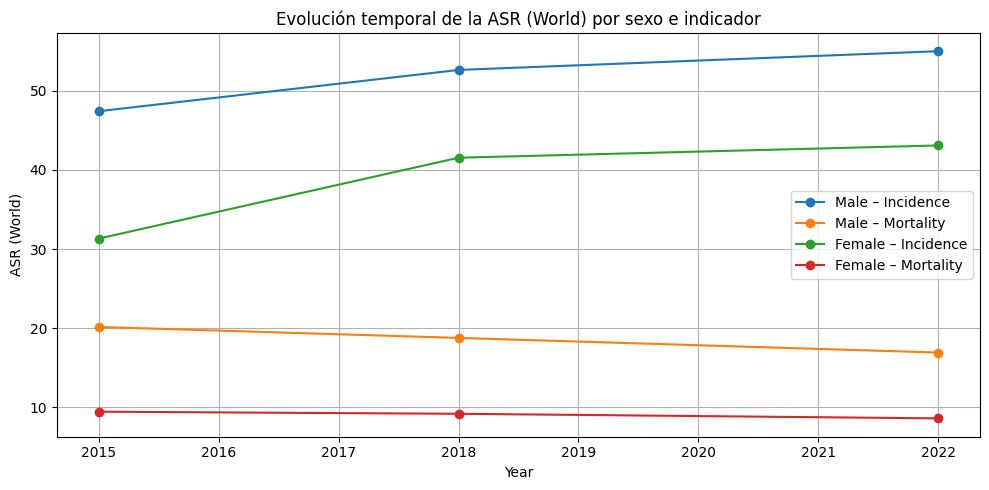

In [153]:
df_trend = (
    df_merged
    .dropna(subset=["Year", "ASR (World)", "Sex", "Type"])
    .groupby(["Year", "Sex", "Type"], as_index=False)
    .agg({"ASR (World)": "mean"})
    .sort_values("Year")
)

%matplotlib inline

plt.figure(figsize=(10,5))

for sex in ["Male", "Female"]:
    for t in ["Incidence", "Mortality"]:
        sub = df_trend[(df_trend["Sex"] == sex) & (df_trend["Type"] == t)]
        plt.plot(
            sub["Year"],
            sub["ASR (World)"],
            marker="o",
            label=f"{sex} – {t}"
        )

plt.xlabel("Year")
plt.ylabel("ASR (World)")
plt.title("Evolución temporal de la ASR (World) por sexo e indicador")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig01_figure_ASR_anno.jpg", dpi=300, bbox_inches="tight")
plt.show()


#Se grafica entonces la evolución temporal de la ASR, estratificado por sexo

En a serie temporal no parece evidenciar o estar afecto por el COVID19, los datos del 2018 y 2022 son bastante parecidos, esto también nos podría suponer que no ha evolucionado significativamente la tasa de mortalidad, lo que si queda claro, es que los hombres y mujeres tienen incidencias y mortalidad distintas, con casi los mismo comportamientos pero de magnitud diferente.
En nuestro estudio existen solamente tres años porque son los años que se tiene registro de la cantidad de equipos de radioterapia y su evolución a lo largo de esos tres años registrados, como ya se mencionó en la depuración, se consideró sumarle 5 años a los registros  de los equipos ya que es ese tiempo aproximadamente en el que se puede saber si efectivamente los equipos de radioterapia (A partir de ahora, RT) han surtido efecto en la mortalidad.





Se busca entonces ver como se comporta la mortalidad e incidencia por año.

In [155]:
idx = (
    df_merged
    .groupby(["ISO3", "Sex", "Type"])["Year"]
    .idxmax()
)

df_latest = df_merged.loc[idx].reset_index(drop=True)


<Figure size 1000x500 with 0 Axes>

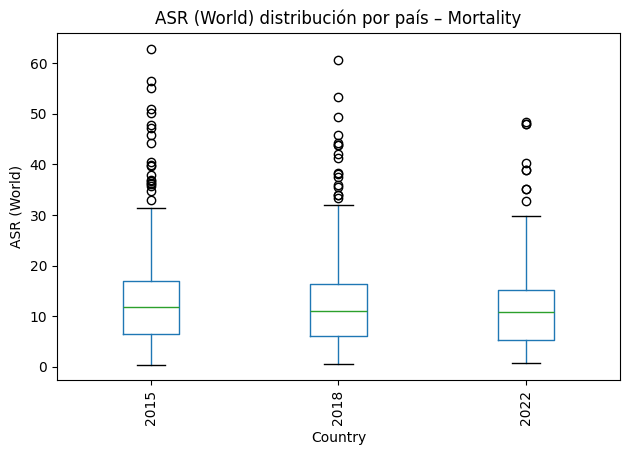

<Figure size 1000x500 with 0 Axes>

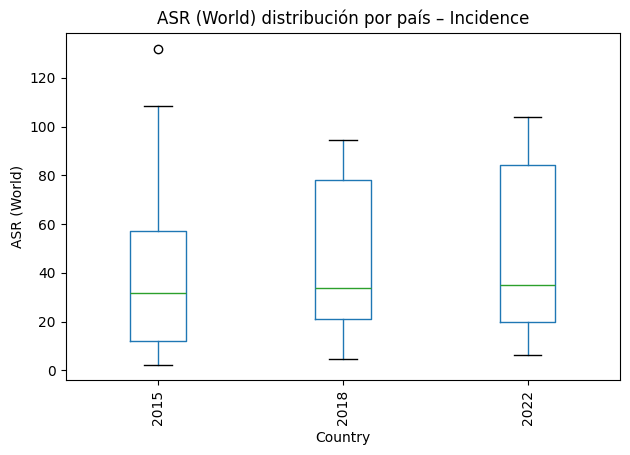

                count       mean        std       min        25%        50%  \
Type      Year                                                                
Incidence 2015  210.0  37.760526  29.306871  2.279390  11.796643  31.704972   
          2018   20.0  45.966859  32.841461  4.611827  21.016206  33.647772   
          2022   30.0  47.842069  34.262574  6.242416  19.646427  34.806863   
Mortality 2015  300.0  13.748971  10.739895  0.388140   6.419846  11.762913   
          2018  280.0  13.035889  10.141584  0.541023   6.052555  11.010309   
          2022  245.0  11.950008   8.931221  0.668701   5.359303  10.791069   

                      75%         max  
Type      Year                         
Incidence 2015  57.320187  132.046692  
          2018  77.994580   94.690075  
          2022  84.118158  103.896318  
Mortality 2015  17.032979   62.917421  
          2018  16.400917   60.588763  
          2022  15.227584   48.374439  


In [156]:
df_plot = df_merged.copy()


for t in df_plot["Type"].unique():
    plt.figure(figsize=(10,5))

    df_plot[df_plot["Type"] == t].boxplot(
        column="ASR (World)",
        by="Year",
        grid=False,
        rot=90
    )

    plt.title(f"ASR (World) distribución por país – {t}")
    plt.suptitle("")
    plt.xlabel("Country")
    plt.ylabel("ASR (World)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/fig02_boxplot_ASR_{t}.jpg", dpi=300, bbox_inches="tight")
    plt.show()

stats_simple = (
    df_plot
    .groupby(["Type", "Year"])["ASR (World)"]
    .describe()
)

print(stats_simple)



Estas figuras muestran la distribución de las tasas de incidencia y mortalidad estandarizadas por edad (ASR World) para los años 2015-2018-2022 mediante diagramas de caja y bigotes. En ambos casos se observa una elevada heterogeneidad entre países, reflejada en amplios rangos intercuartílicos y la presencia sistemática de valores atípicos. Por el contrario, la mortalidad muestra una distribución con outliers muchos outliers, lo que sugiere una mayor dependencia de la capacidad terapéutica de los sistemas sanitarios.

Para determinar si se puede utilizar ambas variables,
Para continuar con el análisis estadístico y valorar que año y paises utilizar en nuestro trabajo, se busca entonces valorar que paises tienen los datos de incidencia y/o mortalidad.


Es importante resaltar desde el principio de que nuestra variable objetivo es la tasa de mortalidad  ASR (World) y ver que relación tiene con los equipos de radioaterapia, incidencia, PIB per capita, sexo, región, etc.



In [160]:
#cuantos paises hay con año, tipo de cancer y tipo

counts = (
    df_merged
    .groupby(
        ["ISO3", "Year", "Cancer label", "Type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

 # cuantos países tienen los datos completos (both) o incompletos?

counts["both"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) > 0)
)

counts["only_incidence"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) == 0)
)

counts["only_mortality"] = (
    (counts.get("Incidence", 0) == 0) &
    (counts.get("Mortality", 0) > 0)
)

summary = {
    "Total combinaciones país–año–cáncer": len(counts),
    "Con incidencia y mortalidad": counts["both"].sum(),
    "Solo incidencia": counts["only_incidence"].sum(),
    "Solo mortalidad": counts["only_mortality"].sum(),
}
print(
    f"Total combinaciones país–año–cáncer: {summary['Total combinaciones país–año–cáncer']}\n"
    f"Con incidencia y mortalidad: {summary['Con incidencia y mortalidad']}\n"
    f"Solo incidencia: {summary['Solo incidencia']}\n"
    f"Solo mortalidad: {summary['Solo mortalidad']}"
)


#Un resumen por año

by_year = (
    counts
    .groupby("Year")[["both", "only_incidence", "only_mortality"]]
    .sum()
)

print(by_year)

#resumen por pais

by_country = (
    counts
    .groupby("ISO3")[["both", "only_incidence", "only_mortality"]]
    .sum()
    .sort_values("both")
)





Total combinaciones país–año–cáncer: 648
Con incidencia y mortalidad: 152
Solo incidencia: 48
Solo mortalidad: 448
Type  both  only_incidence  only_mortality
Year                                      
2015   136              32             104
2018     8               8             216
2022     8               8             128


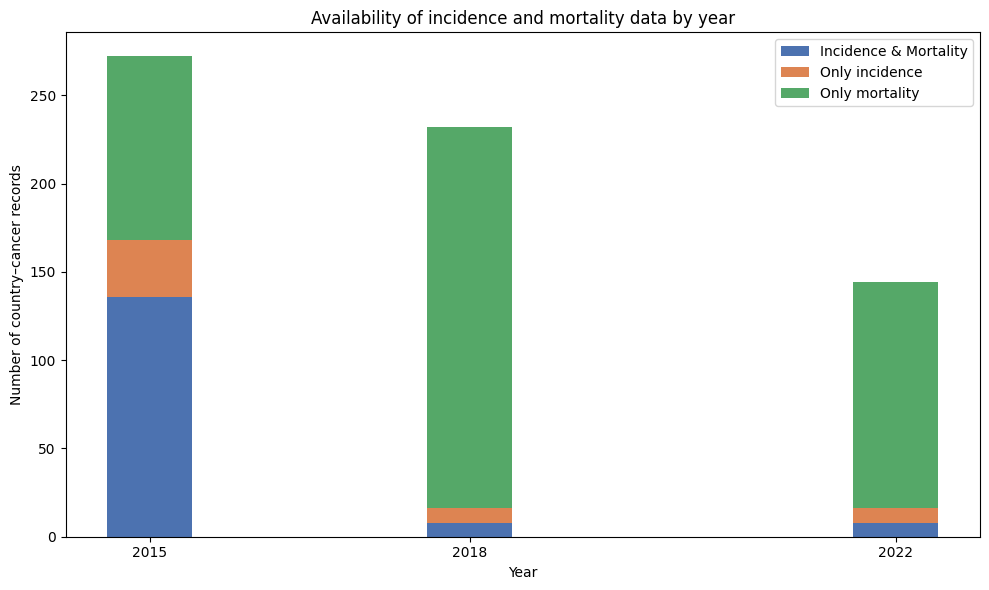

In [161]:
plt.figure(figsize=(10, 6))

plt.bar(
    by_year.index,
    by_year["both"],
    label="Incidence & Mortality",
    color="#4C72B0"
)

plt.bar(
    by_year.index,
    by_year["only_incidence"],
    bottom=by_year["both"],
    label="Only incidence",
    color="#DD8452"
)

plt.bar(
    by_year.index,
    by_year["only_mortality"],
    bottom=by_year["both"] + by_year["only_incidence"],
    label="Only mortality",
    color="#55A868"
)

plt.xlabel("Year")
plt.ylabel("Number of country–cancer records")
plt.title("Availability of incidence and mortality data by year")
plt.legend()
plt.tight_layout()
plt.xticks(by_year.index.astype(int))


plt.show()


Se observó una reducción generalizada en el número de países con datos de incidencia disponibles a partir de 2018 para todos los tipos de cáncer analizados. Este cambio de cobertura limita la comparabilidad temporal de las medias anuales posteriores a dicho año, por lo que los análisis longitudinales se interpretan con cautela y se prioriza el uso de mortalidad como variable objetivo.

In [162]:

df_merged_all = df_merged.copy()


# Quedarse solo con mortalidad
df_merged_all = df_merged_all[df_merged_all["Type"] == "Mortality"].copy()



# Ver qué años hay y cuántas observaciones por año
df_merged_all["Year"].value_counts().sort_index()


,count
Year,
2015,300
2018,280
2022,245


Con estos datos, ahora si, se procede a evaluar con gráficos y estadísitcas que se tiene por cada tipo de cancer.

In [163]:
df_merged_all["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Cervix'], dtype=object)

Con la finalidad de entender si existe algún patrón de comportamiento de estos tipos de cancer con variables como PIB y RT, se procede a utilizar graficos de dispersión.

In [164]:
#Se renombran las columnas
df_model = df_merged_all.rename(columns={
    "Cancer label": "Cancer",
    "Region Name": "Region",
   #"Country_harmonized": "Country",
    "ASR (World)" : "ASR",
    "GDP_per_capita" : "GDP",
    "RT_m" : "RT"
})




In [165]:
df_model.head()

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer,Sex,Type,ASR,Region,RT,GDP,TAC,GammaC,MRI,Mammography,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0


Se grafica las dispersiones.

In [166]:
df_model['log_GDP'] = np.log(df_model['GDP'])

In [168]:
def plot_all_cancers(df, x, y):
    fig = px.scatter(
        df,
        x=x,
        y=y,
        color="Cancer",
        facet_col="Sex",
        facet_row="Year",
        hover_name="ISO3",
        title=f"Grafica de dispersion entre {x} y {y} por tipo de cáncer, año y sexo"
    )
    fig.update_layout(height=800, width=1000)
    plt.savefig(f"{fig_dir}/scatter {x} vs {y} para {"Sex"}.jpg", dpi=300, bbox_inches="tight")
    fig.show()



plot_all_cancers(df_model, "log_GDP", "ASR")

plot_all_cancers(df_model, "RT", "ASR")

<Figure size 640x480 with 0 Axes>

Se observa una tendencia general a que, a mayor PIB per cápita (log_GDP), menor es la Tasa de Mortalidad Estandarizada por Edad (ASR) pero con cierto umbral, donde, un menor per capita supone menor mortalidad, pero a medida que crece hasta cierto punto, baja, esto posiblemente se debe al tabaquismo, contaminación u otro factor no lineal. Esto sugiere que el desarrollo económico hasta cierto punto puede ayudar, asi conjuntamente el sistema sanitario, ambos juegan un papel crucial en la reducción de la mortalidad por cáncer. Sin embargo, esta relación no es perfectamente lineal y varía entre cánceres. Por ejemplo, algunos cánceres pueden mostrar una disminución más pronunciada que otros a medida que aumenta el PIB.

ASR vs. Radioterapia (RT): La relación entre la disponibilidad de equipos de radioterapia y la mortalidad es más compleja y específica de cada cáncer.


Cáncer de Cérvix: Visualmente, es probable que se observe que un aumento en la disponibilidad de RT se correlaciona con una disminución en la ASR, especialmente en rangos bajos de RT, lo que podría ser debido a un efecto umbral. Los puntos de datos para este cáncer se concentran en la parte inferior izquierda de los gráficos cuando hay poca RT y se desplazan aún mas hacia abajo y a la derecha a medida que aumenta la RT.
Cáncer de Mama y Próstata: Para estos cánceres, la relación con la RT parece menos consistente o más dispersa. Los puntos de datos pueden estar más agrupados o mostrar una correlación más débil.

Diferencias por Sexo y Año: Los gráficos revelan que las tendencias pueden variar entre hombres y mujeres para el mismo tipo de cáncer, y también a lo largo de los años, usando el cancer de pulmon para este fin.


Con el objetivo de identificar las variables que podrían influir en la tasa de mortalidad, se realiza un análisis mediante una matriz de correlaciones, diferenciando por sexo, dado que los patrones de incidencia y mortalidad presentan comportamientos significativamente distintos entre hombres y mujeres.


In [169]:
df_model_f = df_model[df_model["Sex"] == "Female"].copy()
df_model_f.drop(columns=["Population_male", "Type", "Sex"], inplace=True)


In [170]:
df_model_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495 entries, 1 to 1084
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               495 non-null    int64  
 1   Population         495 non-null    float64
 2   Population_female  495 non-null    float64
 3   ISO3               495 non-null    object 
 4   Population id      495 non-null    int64  
 5   Cancer             495 non-null    object 
 6   ASR                495 non-null    float64
 7   Region             495 non-null    object 
 8   RT                 495 non-null    float64
 9   GDP                495 non-null    float64
 10  TAC                495 non-null    float64
 11  GammaC             495 non-null    float64
 12  MRI                495 non-null    float64
 13  Mammography        495 non-null    float64
 14  PET                495 non-null    float64
 15  log_GDP            495 non-null    float64
dtypes: float64(11), int64(2), obje

In [171]:
df_model_m = df_model[df_model["Sex"] == "Male"].copy()
df_model_m.drop(columns=["Population_female", "Type", "Sex"], inplace=True)
df_model_m.head()


,Year,Population,Population_male,ISO3,Population id,Cancer,ASR,Region,RT,GDP,TAC,GammaC,MRI,Mammography,PET,log_GDP
0,2015,1292275.0,648341.0,MUS,480,Lung,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0,9.172695
3,2015,1292275.0,648341.0,MUS,480,Prostate,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0,9.172695
5,2018,1288833.0,646826.0,MUS,480,Lung,10.543072,Africa,2.41,11818.748062,6.43,2.41,4.82,0.00,0.0,9.377442
8,2018,1288833.0,646826.0,MUS,480,Prostate,12.165378,Africa,2.41,11818.748062,6.43,2.41,4.82,0.00,0.0,9.377442
10,2022,1276130.0,638999.0,MUS,480,Lung,10.937588,Africa,3.14,10246.501746,0.00,0.00,0.00,0.00,0.0,9.234692


In [172]:
df_model_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 1083
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             330 non-null    int64  
 1   Population       330 non-null    float64
 2   Population_male  330 non-null    float64
 3   ISO3             330 non-null    object 
 4   Population id    330 non-null    int64  
 5   Cancer           330 non-null    object 
 6   ASR              330 non-null    float64
 7   Region           330 non-null    object 
 8   RT               330 non-null    float64
 9   GDP              330 non-null    float64
 10  TAC              330 non-null    float64
 11  GammaC           330 non-null    float64
 12  MRI              330 non-null    float64
 13  Mammography      330 non-null    float64
 14  PET              330 non-null    float64
 15  log_GDP          330 non-null    float64
dtypes: float64(11), int64(2), object(3)
memory usage: 43.8+ KB


Ahora, se buscan las variables que nos interesa

In [192]:
df = df_model_m.copy()


cols_corr_m = [
    "ASR", "RT", "Population_male", "log_GDP", "TAC",	"GammaC",	"MRI",
  	"PET"
]

In [193]:


corr_m = df[cols_corr_m].corr()
corr_m

,ASR,RT,Population_male,log_GDP,TAC,GammaC,MRI,PET
ASR,1.000000,0.017513,-0.106466,-0.018381,0.041681,0.055178,0.023260,-0.003079
RT,0.017513,1.000000,0.279691,0.755825,0.190185,0.281378,0.246119,0.370242
Population_male,-0.106466,0.279691,1.000000,0.121111,0.095805,0.138861,0.166912,0.101677
log_GDP,-0.018381,0.755825,0.121111,1.000000,0.255385,0.320403,0.322885,0.366198
TAC,0.041681,0.190185,0.095805,0.255385,1.000000,0.453706,0.875834,0.732088
GammaC,0.055178,0.281378,0.138861,0.320403,0.453706,1.000000,0.515837,0.621010
MRI,0.023260,0.246119,0.166912,0.322885,0.875834,0.515837,1.000000,0.684376
PET,-0.003079,0.370242,0.101677,0.366198,0.732088,0.621010,0.684376,1.000000


Lo que se puede ver es que la señal es bastante débil si juntamos las variables, ahora bien, debido a que cada tipo de cancer tiene su protocolo y no son comparables, se estratifica por tipo de cancer.

In [194]:
def plot_corr_heatmap(df, cols_corr, cancer):
  df_ = df[df["Cancer"] == cancer]

  corr_ = df_[cols_corr].corr()

  plt.figure(figsize=(8, 6))
  sns.heatmap(
    corr_,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
  )
  plt.title("Correlation heatmap – " f"{cancer}")
  plt.tight_layout()
  plt.show()
  plt.savefig(f"{fig_dir}/heatmap_corr_{cancer} para {"Sex"}.jpg", dpi=300, bbox_inches="tight")


  return corr_, df_

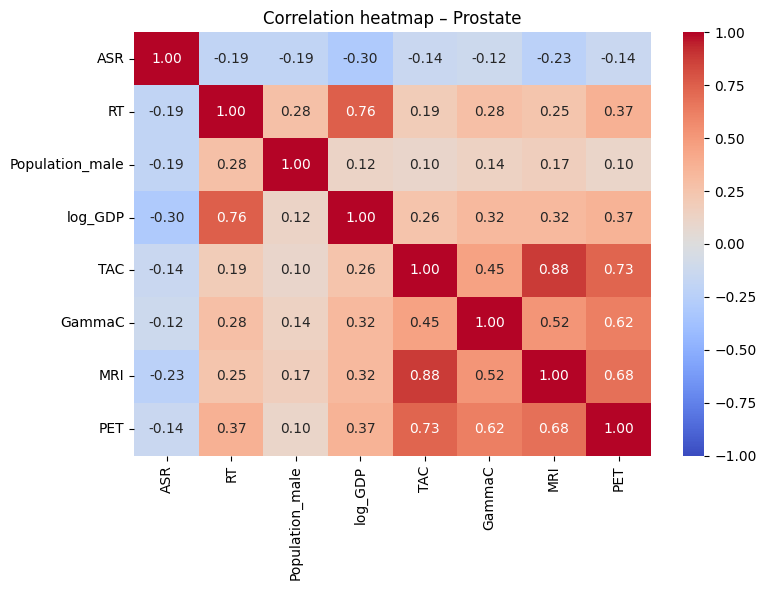

<Figure size 640x480 with 0 Axes>

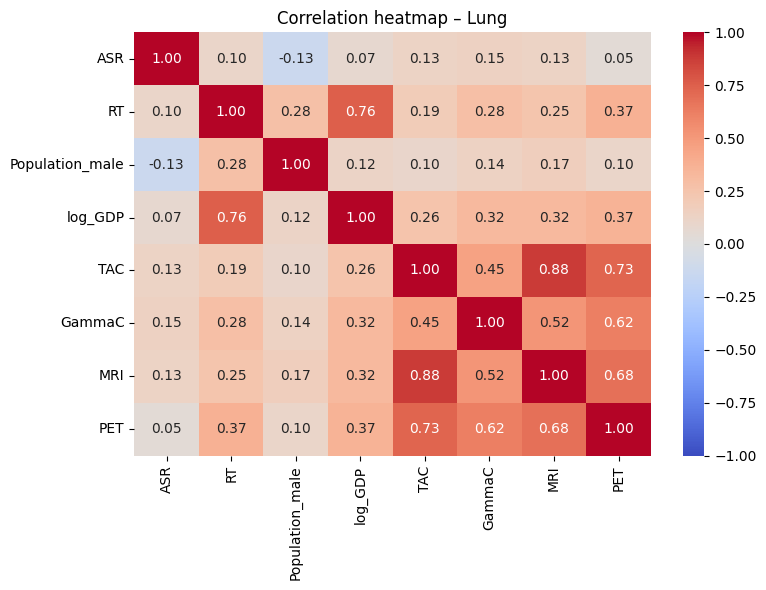

<Figure size 640x480 with 0 Axes>

In [195]:
corr_prostate, df_prostate = plot_corr_heatmap(df_model_m, cols_corr_m, "Prostate")

corr_lung_m, df_lung_m = plot_corr_heatmap(df_model_m, cols_corr_m, "Lung")


En estos mapas de calor podemos ver una muy fuerte correlación entre el pib per capita y los equipos RT, pero

In [196]:
df = df_model_f.copy()


cols_corr_f = [
    "ASR", "RT", "Population_female", "log_GDP", "TAC",	"GammaC",	"MRI",
    "Mammography",	"PET"
]

corr = df[cols_corr_f].corr()
corr

,ASR,RT,Population_female,log_GDP,TAC,GammaC,MRI,Mammography,PET
ASR,1.000000,0.072251,-0.010725,0.031906,-0.034285,0.073524,-0.047965,-0.010872,0.018647
RT,0.072251,1.000000,0.275557,0.755825,0.190185,0.281378,0.246119,0.123655,0.370242
Population_female,-0.010725,0.275557,1.000000,0.117930,0.099280,0.133071,0.169448,0.108882,0.101088
log_GDP,0.031906,0.755825,0.117930,1.000000,0.255385,0.320403,0.322885,0.155965,0.366198
TAC,-0.034285,0.190185,0.099280,0.255385,1.000000,0.453706,0.875834,0.493833,0.732088
GammaC,0.073524,0.281378,0.133071,0.320403,0.453706,1.000000,0.515837,0.496773,0.621010
MRI,-0.047965,0.246119,0.169448,0.322885,0.875834,0.515837,1.000000,0.559846,0.684376
Mammography,-0.010872,0.123655,0.108882,0.155965,0.493833,0.496773,0.559846,1.000000,0.468633
PET,0.018647,0.370242,0.101088,0.366198,0.732088,0.621010,0.684376,0.468633,1.000000


El mapa de calor revela patrones heterogéneos en la relación entre densidad de radioterapia y mortalidad según el tipo de cáncer. En particular, el cáncer de cérvix muestra una reducción abrupta de la mortalidad al superar niveles medios de dotación de radioterapia, evidenciando un claro efecto umbral. En contraste, otros cánceres como pulmón presentan patrones inversos, probablemente asociados a diferencias en detección y registro más que a un efecto causal directo de la radioterapia. Estos resultados refuerzan la necesidad de enfoques diferenciados en la planificación de infraestructuras de radioterapia, priorizando aquellos cánceres donde el impacto potencial es mayor.

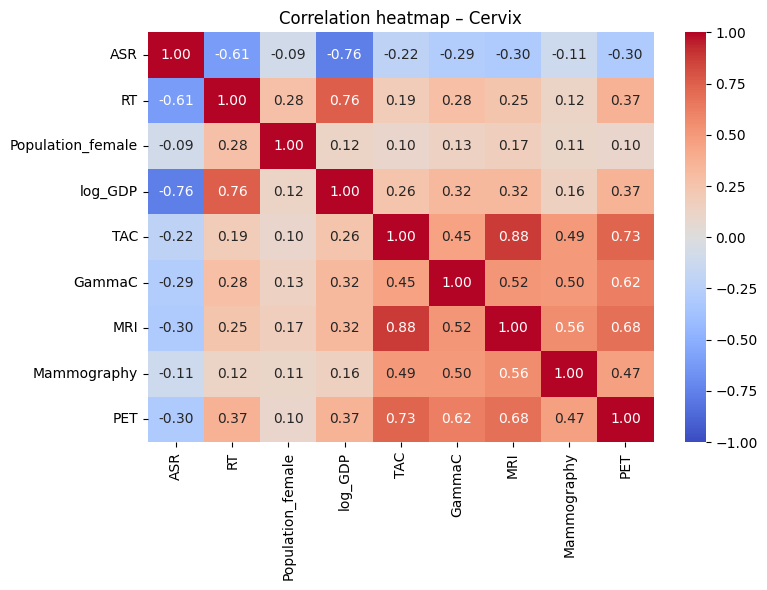

<Figure size 640x480 with 0 Axes>

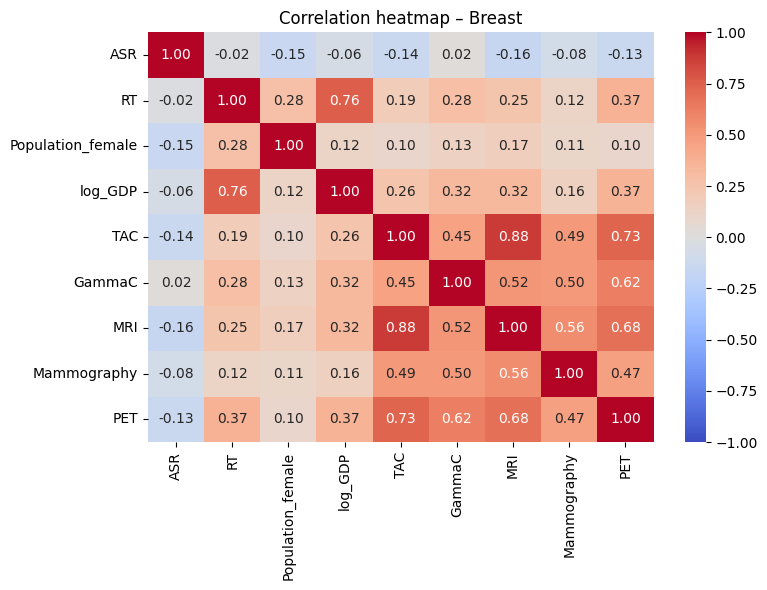

<Figure size 640x480 with 0 Axes>

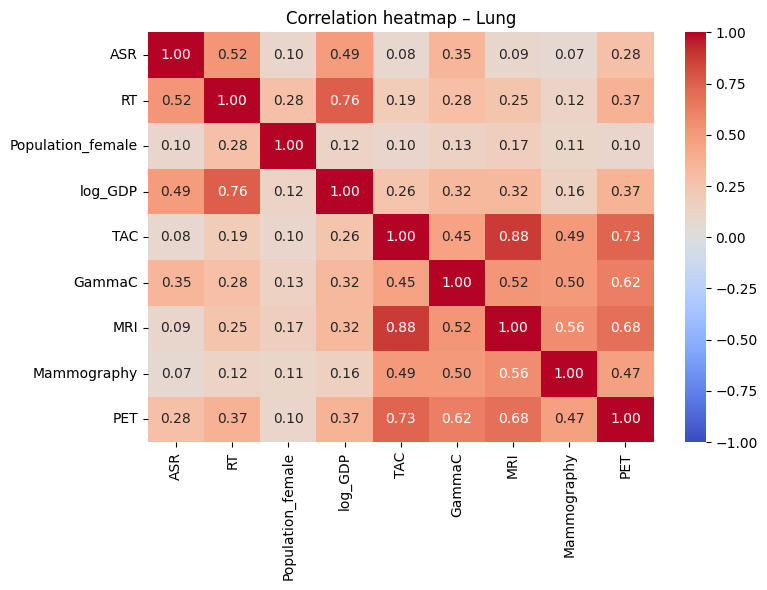

<Figure size 640x480 with 0 Axes>

In [197]:
corr_cervix, df_cervix = plot_corr_heatmap(df_model_f, cols_corr_f, "Cervix")

corr_breast, df_breast = plot_corr_heatmap(df_model_f, cols_corr_f, "Breast")

corr_lung_f, df_lung_f = plot_corr_heatmap(df_model_f, cols_corr_f, "Lung")

Analizando los mapas de colores, encontramos que paradojicamente existen tipos de cáncer que aumentan con la cantidad de equipos y PIB per capita, este es el caso de pulmón en ambos sexos, sin embargo, se puede ver claramente que tanto para cervix como prostata, tratamientos muy bien protocolizados en tratamientos con radioterapia externa, si tienen un gran impacto, el valor negativo nos indica que disminuye a media que aumenta el número de la variable predictora.

Entonces, nos centraremos en estos dos tipo de canceres.



Ahora, se busca si por regiones, estos dos tipo de canceres cambia.

A partir de aquí y debido a que tenemos solamente dos variables predictoras, utilizaremos métodos adecuados a lo que tenemos disponible.

¿Existe un umbral de numero de RT donde se puede optimizar sus bondades y aún así optener buenos resultados epidemiológicos tanto en próstata con en cervix?
O ¿Entre más equipos existe menos mortalidad?

Empezando con un modelo base sencillo: regresión lineal.

### Regresión lineal para hombres (ASR ~ log_GDP + RT)

In [198]:
df_cervix.describe()

,Year,Population,Population_female,Population id,ASR,RT,GDP,TAC,GammaC,MRI,Mammography,PET,log_GDP
count,165.000000,1.650000e+02,1.650000e+02,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,2018.096970,3.089068e+07,1.561041e+07,406.406061,3.667999,4.536242,29072.858533,9.064909,3.091091,4.821030,41.443758,0.605230,9.870272
std,2.839667,5.935653e+07,2.973329e+07,237.368703,2.708875,3.416306,24669.242946,15.218031,5.889276,8.011149,87.535563,1.303738,0.988413
min,2015.000000,3.563330e+05,1.771300e+05,32.000000,0.388140,0.000000,1283.520304,0.000000,0.000000,0.000000,0.000000,0.000000,7.157362
25%,2015.000000,4.323387e+06,2.086352e+06,208.000000,1.446800,1.470000,10024.819111,0.000000,0.000000,0.000000,0.000000,0.000000,9.212819
50%,2018.000000,9.064677e+06,4.574595e+06,380.000000,3.074132,3.960000,20221.103686,2.910000,0.000000,0.800000,0.000000,0.000000,9.914482
75%,2022.000000,3.729500e+07,1.878008e+07,608.000000,5.101708,6.780000,41929.754911,13.250000,3.700000,8.140000,40.840000,0.570000,10.643751
max,2022.000000,3.415340e+08,1.698613e+08,862.000000,13.175513,13.160000,116926.759594,101.700000,48.370000,46.160000,521.600000,8.290000,11.669303


In [203]:
model_prostate_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC + GammaC + MRI + Mammography + PET", # Añadida la coma aquí
    data=df_prostate
).fit()

print(model_prostate_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     3.449
Date:                Fri, 13 Feb 2026   Prob (F-statistic):            0.00184
Time:                        21:38:43   Log-Likelihood:                -480.63
No. Observations:                 165   AIC:                             977.3
Df Residuals:                     157   BIC:                             1002.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      25.8640      5.056      5.116      

### Evaluación de RMSE y Validación Cruzada para Cáncer de Próstata

In [204]:
# --- RMSE para el modelo OLS de Próstata ya ajustado ---
X_prostate = df_prostate[["log_GDP", "RT"]]
y_pred_prostate = model_prostate_ols.predict(X_prostate)
rmse_prostate = np.sqrt(mean_squared_error(df_prostate["ASR"], y_pred_prostate))
print(f"RMSE (Modelo OLS Próstata): {rmse_prostate:.3f}")

# --- Validación Cruzada para Próstata ---

y_prostate = df_prostate["ASR"]

lr_prostate = LinearRegression()
cv_prostate = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_prostate = cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="r2"
)

rmse_scores_prostate = -cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Próstata): {r2_scores_prostate.mean():.3f} ± {r2_scores_prostate.std():.3f}")
print(f"CV RMSE (Próstata): {rmse_scores_prostate.mean():.3f} ± {rmse_scores_prostate.std():.3f}")

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error evaluating factor: NameError: name 'TAC' is not defined
    ASR ~ log_GDP + RT + TAC + GammaC + MRI + Mammography + PET
                         ^^^

En las métricas se puede observar que tanto el GDP como RT explican muy poca de la variabilidad de la mortalidad documentada, tan solo un 8%. Otro punto a considerar es que el coeficiente, además de ser casi nulo para RT, es positivo, algo que no tiene mucho sentido, viendo los diagramas de dispersión se puede ver que son puntos dispersos.

### Regresión lineal para mujeres (ASR ~ log_GDP + RT)

In [223]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC +\tGammaC +\tMRI + PET", # Añadida la coma aquí
    data=df_cervix
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     37.00
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           8.81e-28
Time:                        22:15:16   Log-Likelihood:                -325.66
No. Observations:                 165   AIC:                             665.3
Df Residuals:                     158   BIC:                             687.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.1784      1.966     11.283      0.0

Con resultados donde se predice el 58% de la variabilidad, se puede decir que el PIB per capita es el dominante y el intervalo está lejos de cero. Esto es coherente con que la infraestructura sanitaria está correlacionada con desarrollo economico.

Sin embargo, el resto de variables podrían presentar outliers que podrían distorsionar el modelo.

In [230]:
residuals = model_cervix_ols.resid_pearson
outliers = df_cervix[np.abs(residuals) > 3]

outliers


,Year,Population,Population_female,ISO3,Population id,Cancer,ASR,Region,RT,GDP,TAC,GammaC,MRI,Mammography,PET,log_GDP
24,2015,56723537.0,29194266.0,ZAF,710,Cervix,12.971971,Africa,0.60,6112.273825,1.02,0.56,0.24,9.11,0.060,8.718054
29,2018,58613001.0,30211846.0,ZAF,710,Cervix,13.175513,Africa,0.57,6914.178032,0.97,0.53,0.23,0.00,0.057,8.841329
969,2018,791556.0,403661.0,GUY,328,Cervix,11.997842,Americas,1.25,6048.386972,3.75,0.00,1.25,0.00,0.000,8.707547


In [233]:
df_cervix_clean = df_cervix.drop(outliers.index).copy()

In [239]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP + RT", # Añadida la coma aquí
    data=df_cervix_clean
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     126.6
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.29e-33
Time:                        22:44:05   Log-Likelihood:                -296.20
No. Observations:                 162   AIC:                             598.4
Df Residuals:                     159   BIC:                             607.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.6347      1.647     13.135      0.0

📊 ANÁLISIS DE LOS RESULTADOS DEL MODELO OLSBasándome en los resultados que compartiste, aquí está mi evaluación del modelo de regresión para la mortalidad por cáncer cervical (ASR):✅ ASPECTOS POSITIVOS:1. Bondad de Ajuste:R-squared: 0.584 - El modelo explica el 58.4% de la variabilidad en la mortalidad por cáncer cervical, lo cual es razonablemente bueno.Adj. R-squared: 0.568 - Muy cercano al R², indicando que las variables incluidas son apropiadas.2. Significancia Global:F-statistic: 37.00 con Prob (F-statistic): 8.81e-28 - El modelo en su conjunto es altamente significativo.3. Variables Significativas:log_GDP: coef = -1.8328, p = 0.000 (altamente significativo)

Por cada unidad de aumento en log_GDP, la mortalidad disminuye en 1.83 unidades. Esto tiene sentido: mayor desarrollo económico se asocia con menor mortalidad.

RT (Radioterapia): coef = -0.0709, p = 0.268 (no significativo, pero negativo como se esperaría)

⚠️ PROBLEMAS IDENTIFICADOS:1. Variables NO Significativas:TAC: p = 0.491GammaC: p = 0.618MRI: p = 0.208PET: p = 0.669Ninguna de estas tecnologías de diagnóstico muestra significancia estadística. Esto podría indicar:Multicolinealidad entre estas variablesQue su disponibilidad no impacta directamente en la mortalidadQue el efecto está mediado por otras variables (como el GDP)2. Durbin-Watson: 0.817Este valor sugiere autocorrelación positiva en los residuos (lo ideal sería cercano a 2). Esto puede indicar que hay patrones en los datos que el modelo no está capturando.3. Jarque-Bera: 115.649 con Prob(JB): 7.71e-26Los residuos NO siguen una distribución normal, lo cual viola uno de los supuestos de la regresión OLS. Esto puede afectar la validez de las inferencias estadísticas.4. Kurtosis: 6.229Indica que los residuos tienen colas más pesadas de lo normal, sugiriendo la presencia de outliers.

In [296]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP", # Añadida la coma aquí
    data=df_cervix_clean
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     252.8
Date:                Sat, 14 Feb 2026   Prob (F-statistic):           9.36e-35
Time:                        00:59:07   Log-Likelihood:                -296.58
No. Observations:                 162   AIC:                             597.2
Df Residuals:                     160   BIC:                             603.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.6022      1.207     18.723      0.0

### Evaluación de RMSE y Validación Cruzada para Cáncer de Cérvix

In [209]:
# --- RMSE para el modelo OLS de Cérvix ya ajustado ---
y_pred_cervix = model_cervix_ols.predict(df_cervix)
rmse_cervix = np.sqrt(mean_squared_error(df_cervix["ASR"], y_pred_cervix))
print(f"RMSE (Modelo OLS Cérvix): {rmse_cervix:.3f}")

# --- Validación Cruzada para Cérvix ---
X_cervix = df_cervix[["log_GDP", "RT"]]
y_cervix = df_cervix["ASR"]

lr_cervix = LinearRegression()
cv_cervix = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_cervix = cross_val_score(
    lr_cervix, X_cervix, y_cervix,
    cv=cv_cervix,
    scoring="r2"
)

rmse_scores_cervix = -cross_val_score(
    lr_cervix, X_cervix, y_cervix,
    cv=cv_cervix,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Cérvix): {r2_scores_cervix.mean():.3f} ± {r2_scores_cervix.std():.3f}")
print(f"CV RMSE (Cérvix): {rmse_scores_cervix.mean():.3f} ± {rmse_scores_cervix.std():.3f}")

RMSE (Modelo OLS Cérvix): 1.741
CV R² (Cérvix): 0.556 ± 0.081
CV RMSE (Cérvix): 1.756 ± 0.228


Antes de continuar, se procede a verificar Multicolinealidad VIF

Aunque el coeficiente de determinación obtenido en validación cruzada es relativamente elevado para este tipo de datos agregados, los resultados se interpretan con cautela, dado que pueden reflejar estructuras latentes no completamente capturadas por el modelo, como diferencias regionales.

en el caso de Cervix, estas dos variables explican el 58%  de la variabilidad de la tasa de mortalidad en Cervix, usando OLS. A pesar de tener un coeficiente bastante pequeño para RT.

En este caso, R2 es bastante robusto y útil para entender el fenómeno, según este método, el 58% de la variabilidad de ASR es explicada con estas dos variables, pib per capita y RT, también es cierto que RT tiene un valor bastante bajo, sin embargo, posiblemente si estudiamos con otros modelos su comportamiento, podríamos encontrar algo más interesante.

Antes de continuar, se dejará aquí plasmado los resultados de OLS del resto de tipo de cancer estudiados, con el fin de saber su comportamiento a pesar de no encontrar significancia usando la matriz de correlación.


Para mama

In [211]:
model_breast_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC +\tGammaC +\tMRI + PET + Mammography",
    data=df_breast
).fit()

print(model_breast_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.255
Date:                Fri, 13 Feb 2026   Prob (F-statistic):              0.276
Time:                        21:44:08   Log-Likelihood:                -430.13
No. Observations:                 165   AIC:                             876.3
Df Residuals:                     157   BIC:                             901.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      15.3256      3.723      4.117      

##Para pulmon en mujeres

In [214]:
model_lung_f_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC +\tGammaC +\tMRI + PET",
    data=df_lung_f
).fit()

print(model_lung_f_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     14.99
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.54e-13
Time:                        21:58:21   Log-Likelihood:                -484.36
No. Observations:                 165   AIC:                             982.7
Df Residuals:                     158   BIC:                             1004.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.6444      5.143     -0.903      0.3

In [295]:
model_lung_m_ols = smf.ols(
    "ASR ~ log_GDP + RT + TAC +\tGammaC +\tMRI + PET",
    data=df_lung_m
).fit()

print(model_lung_m_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9200
Date:                Sat, 14 Feb 2026   Prob (F-statistic):              0.339
Time:                        00:57:54   Log-Likelihood:                -657.80
No. Observations:                 165   AIC:                             1320.
Df Residuals:                     163   BIC:                             1326.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.9591     10.278      1.553      0.1

Al incluir simultáneamente múltiples indicadores de infraestructura tecnológica, el modelo muestra una pérdida sustancial de capacidad explicativa y significación global, lo que sugiere la presencia de colinealidad y estructura no modelada. Este resultado refuerza la necesidad de enfoques parsimoniosos y regularizados para este tipo de datos.

Siguiendo la linea de buscar el mejor modelo, procedemos con alguno basado en arboles, pero bastante limitado ya que la muestra es limitada.

Primeramente haremos un modelo con la variable más significativa que es el PIB per capita.


COMPARACIÓN DE MODELOS
           Modelo  R² (CV)
Gradient Boosting 0.614909
    Random Forest 0.614509
          OLS pib 0.554713
            Lasso 0.553424
      Elastic Net 0.552134
            Ridge 0.551173


/tmp/ipython-input-834400879.py:85: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




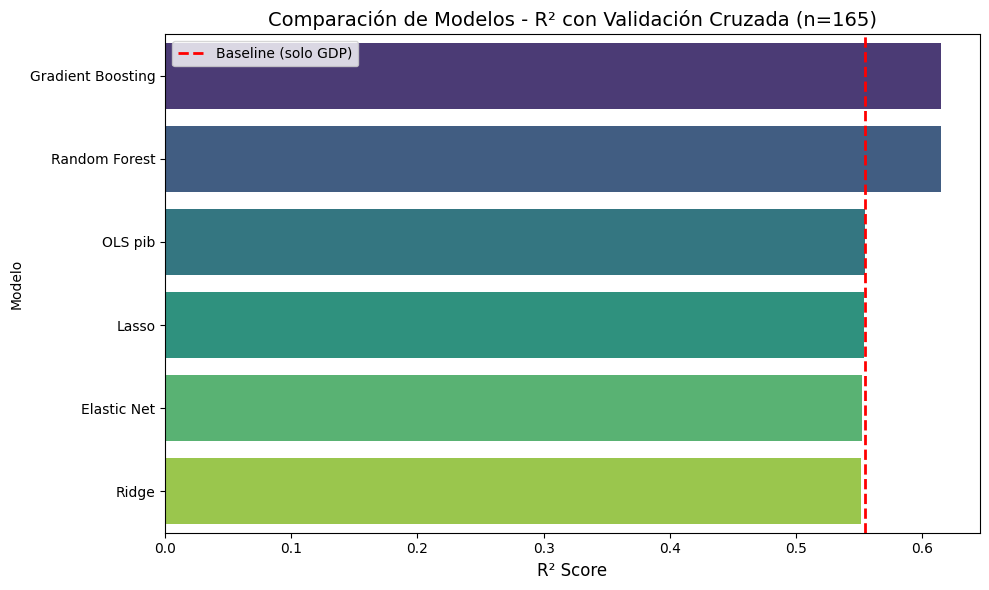

In [244]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler


rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

y = df_cervix["ASR"]
X = df_cervix[["log_GDP"]]
X_baseline = df_cervix[['log_GDP']]

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Configurar validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario para almacenar resultados
resultados = {}

# 1. OLS baseline (solo log_GDP)
ols_baseline = LinearRegression()
scores_ols = cross_val_score(ols_baseline, X_baseline, y, cv=cv, scoring='r2')
resultados['OLS pib'] = scores_ols.mean()

# 2. Ridge
X_scaled_ridge = scaler.fit_transform(X) # Re-escalar para cada modelo si X es modificado
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
scores_ridge = cross_val_score(ridge, X_scaled_ridge, y, cv=cv, scoring='r2')
resultados['Ridge'] = scores_ridge.mean()

# 3. Lasso
X_scaled_lasso = scaler.fit_transform(X) # Re-escalar para cada modelo
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
scores_lasso = cross_val_score(lasso, X_scaled_lasso, y, cv=cv, scoring='r2')
resultados['Lasso'] = scores_lasso.mean()

# 4. Elastic Net
X_scaled_elastic = scaler.fit_transform(X) # Re-escalar para cada modelo
elastic = ElasticNetCV(alphas=np.logspace(-3, 3, 30), l1_ratio=[0.3, 0.5, 0.7], cv=5, max_iter=10000)
scores_elastic = cross_val_score(elastic, X_scaled_elastic, y, cv=cv, scoring='r2')
resultados['Elastic Net'] = scores_elastic.mean()

# 5. Random Forest (limitado)

rf_model = RandomForestRegressor(n_estimators=50, max_depth=3, min_samples_split=10,
                           min_samples_leaf=5, random_state=42)
scores_rf = cross_val_score(rf_model, X, y, cv=cv, scoring='r2')
resultados['Random Forest'] = scores_rf.mean()

# 6. Gradient Boosting (conservador)
# X no necesita escalado para GradientBoostingRegressor
gb_model = GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, max_depth=2,
                               min_samples_split=10, min_samples_leaf=5, random_state=42)
scores_gb = cross_val_score(gb_model, X, y, cv=cv, scoring='r2')
resultados['Gradient Boosting'] = scores_gb.mean()

# Crear dataframe de resultados
df_resultados = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'R² (CV)': list(resultados.values())
}).sort_values('R² (CV)', ascending=False)

print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS")
print("="*50)
print(df_resultados.to_string(index=False))
print("="*50)

# Visualizar

plt.figure(figsize=(10, 6))
sns.barplot(data=df_resultados, y='Modelo', x='R² (CV)', palette='viridis')
plt.title('Comparación de Modelos - R² con Validación Cruzada (n=' + str(len(df_cervix)) + ')', fontsize=14)
plt.xlabel('R² Score', fontsize=12)
plt.axvline(x=resultados['OLS pib'], color='red', linestyle='--',
            label='Baseline (solo GDP)', linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()

Dado el tamaño muestral limitado, los modelos basados en árboles se restringieron a un número reducido de variables y a profundidades muy bajas, con el objetivo de evitar sobreajuste y preservar la interpretabilidad.

Siguiendo los resultados de nuestro modelo base, parece que Gradient Boosting es el que mejor se adapta, mejorando un 6% del modelo OLS.
Ahora, analizando la importancia de las caracteristicas, se tiene:

IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING
  Variable  Importancia
0  log_GDP     0.806530
1       RT     0.107528
2      TAC     0.040492
5   GammaC     0.025664
3      MRI     0.018289
4      PET     0.001496



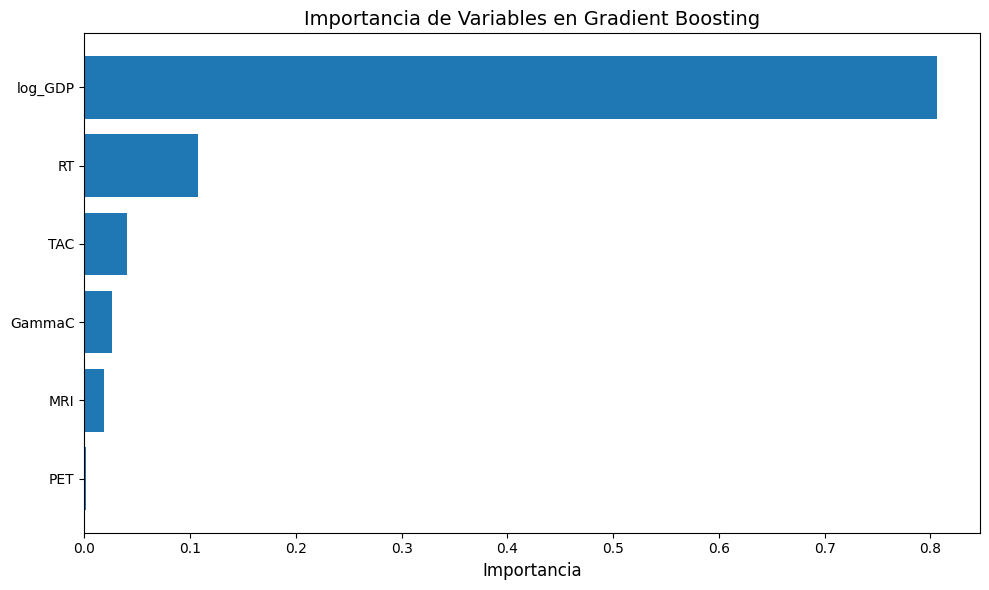

In [254]:
# Entrenar Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import matplotlib.pyplot as plt

gb = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

y = df_cervix["ASR"]
X = df_cervix[["log_GDP", "RT", "TAC", "MRI", "PET", "GammaC"]]

gb.fit(X, y)

# Importancia de características
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)

print("="*50)
print("IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING")
print("="*50)
print(feature_importance)
print()

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importancia'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de Variables en Gradient Boosting', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

PIB domina completamente, es por mucho, el factor mas importante. El resto tiene importancia marginal.


Debido al limitado tamaño muestral, nos quedaremos con los más importantes que son el PIB y RT. Y vuelvo a ejecutar la celda anterior con estas dos variables solamente.





IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING
  Variable  Importancia
0  log_GDP     0.863798
1       RT     0.136202



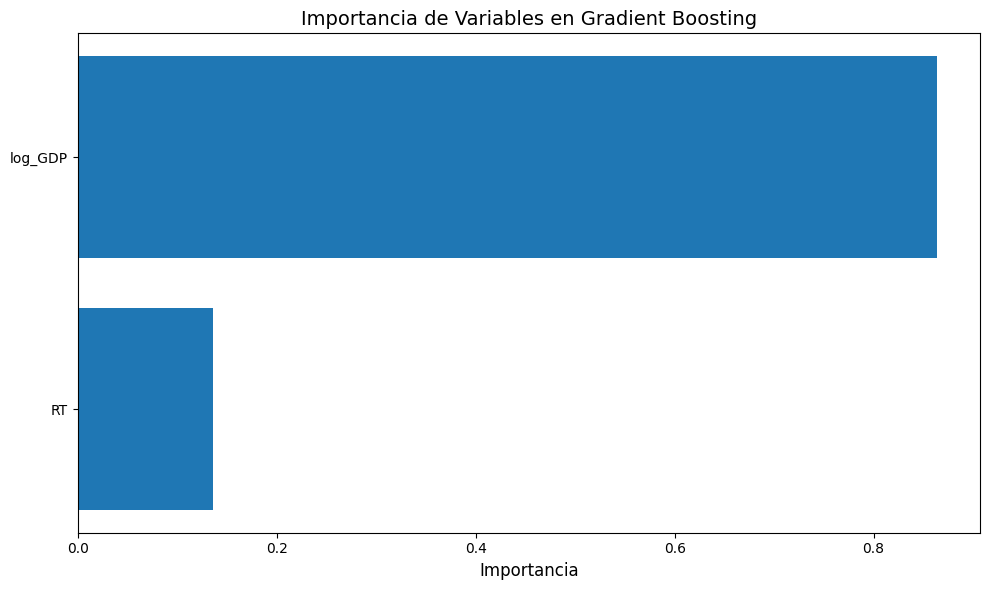

In [280]:
X = df_cervix[["log_GDP", "RT"]]

gb.fit(X, y)

# Importancia de características
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)

print("="*50)
print("IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING")
print("="*50)
print(feature_importance)
print()

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importancia'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de Variables en Gradient Boosting', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

La importancia del 13%, es la segunda variable más importante.

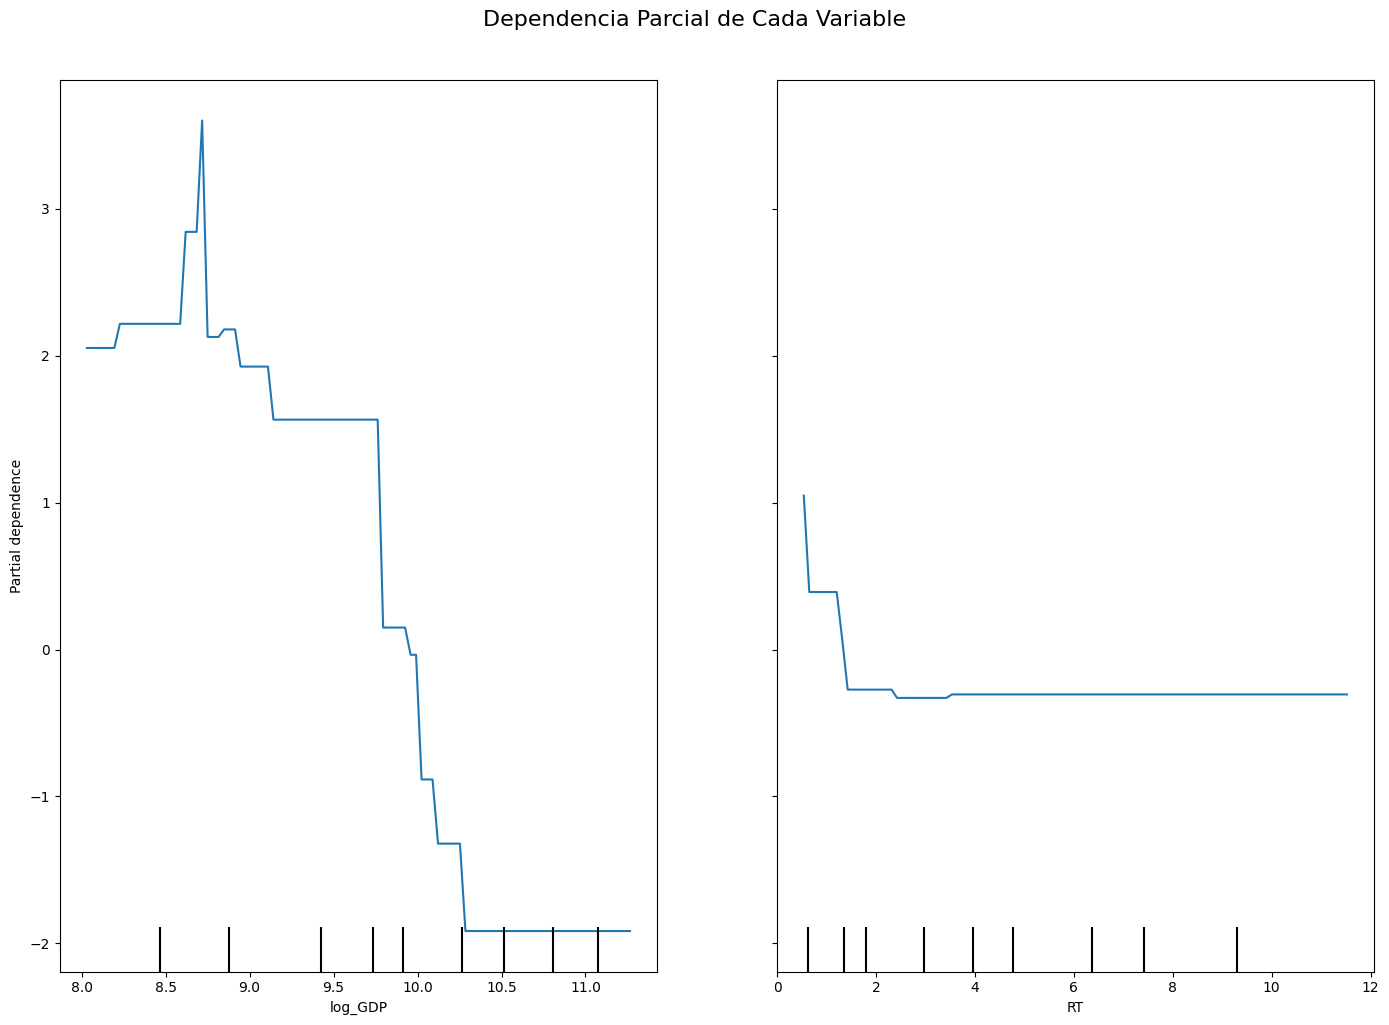

In [281]:
from sklearn.inspection import PartialDependenceDisplay

# Ver cómo cada variable afecta la predicción
fig, ax = plt.subplots(figsize=(14, 10))
features_to_plot = list(range(len(X.columns)))

PartialDependenceDisplay.from_estimator(
    gb,
    X,
    features_to_plot,
    feature_names=X.columns,
    ax=ax,
    n_cols=3
)
plt.suptitle('Dependencia Parcial de Cada Variable', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Por esta razón es que este modelo no lineal si mejoraba el modelo, ya que hay un "salto" donde el PIB sube junto con la tasa de mortalidad para luego bajar como debería de corresponder.

Con respecto a los equipos de RT, parece presentar un umbral donde los paises con esa concentración de equipos ayudan a la mortalidad, siendo un poco más de 2/millón de habitantes bajando gradualmente la mortalidad y ya luego el valor se estabiliza, esto lo que quiere deicr es que con países con 1 equipo de radioterapia por 500.000 habitantes debería de considerarse efectivo para los tratamientos. Mas allá de cierto punto, no ayuda mucho. Pero si que tiene impacto pasar de RT=0 a RT=2-3 equipos


Entonces, GB captura la no linealidad de PIB y el efecto umbral de RT, cosa que OLS no captura.

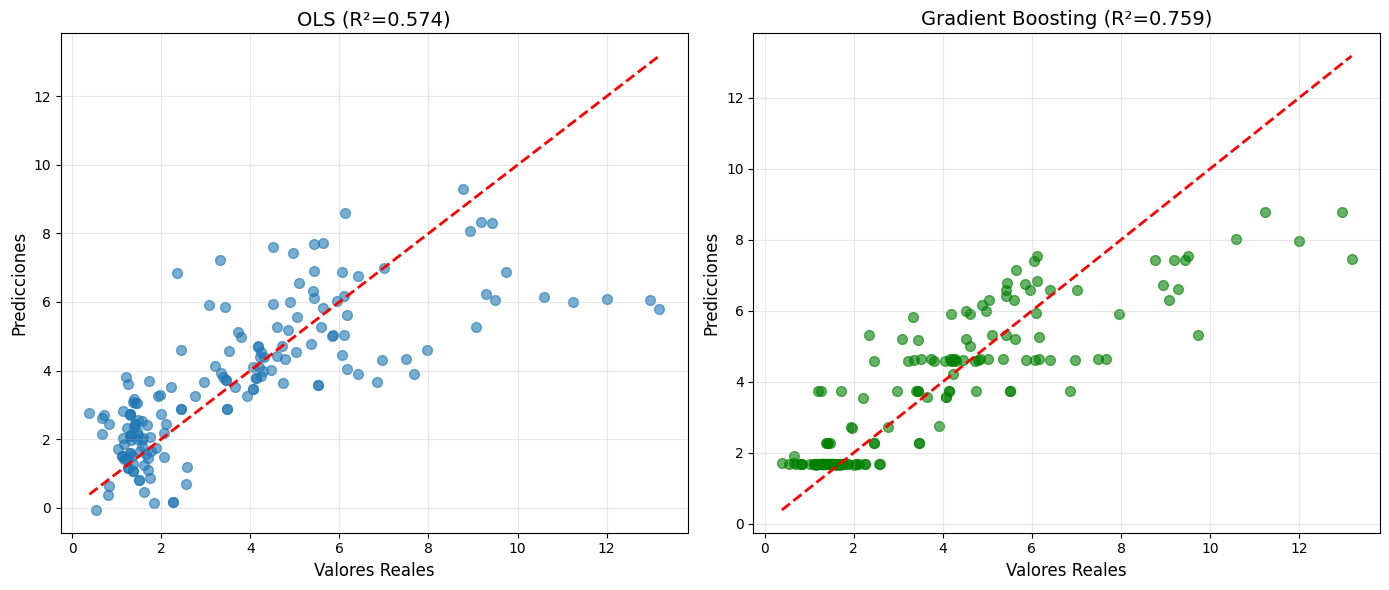


Casos donde Gradient Boosting mejora significativamente: 26

Ejemplos de mejora:
       log_GDP    log_GDP    RT
24    8.718054   8.718054  0.60
29    8.841329   8.841329  0.57
39    7.938513   7.938513  0.66
44    7.502785   7.502785  0.62
104   7.975860   7.975860  0.19
109   8.061017   8.061017  0.18
124  11.410882  11.410882  5.13
134   8.164053   8.164053  1.29
139   8.341888   8.341888  1.34
159  10.279193  10.279193  2.63


In [282]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import r2_score # Importar r2_score aquí

# OLS baseline
ols = LinearRegression()
ols.fit(X_baseline, y)
y_pred_ols = ols.predict(X_baseline)

# Gradient Boosting
y_pred_gb = gb.predict(X)
r2_score_gb = r2_score(y, y_pred_gb)
# Comparar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# OLS
axes[0].scatter(y, y_pred_ols, alpha=0.6, s=50)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Predicciones', fontsize=12)
axes[0].set_title(f'OLS (R²={r2_score(y, y_pred_ols):.3f})', fontsize=14)
axes[0].grid(alpha=0.3)

# Gradient Boosting
axes[1].scatter(y, y_pred_gb, alpha=0.6, s=50, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Predicciones', fontsize=12)
axes[1].set_title(f'Gradient Boosting (R²={r2_score(y, y_pred_gb):.3f})', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Ver dónde mejora GB
diferencia = np.abs(y - y_pred_gb) - np.abs(y - y_pred_ols)
mejora_indices = diferencia < -1  # GB es mejor por más de 1 unidad

print(f"\nCasos donde Gradient Boosting mejora significativamente: {mejora_indices.sum()}")
if mejora_indices.sum() > 0:
    print("\nEjemplos de mejora:")
    print(df_cervix[mejora_indices][['log_GDP'] + list(X.columns)].head(10))

In [289]:
# Calcular intervalos de confianza
from scipy import stats

residuos = y - y_pred_gb
std_residuos = np.std(residuos)

# Intervalo de 95% confianza
intervalo_95 = 1.96 * std_residuos
print(f"Intervalo de confianza 95%: ±{intervalo_95:.2f}")

Intervalo de confianza 95%: ±2.60


El modelo de Gradient Boosting clasifica los países en grupos de riesgo discretos basándose en umbrales en las variables predictoras, reflejando transiciones no lineales en la relación entre desarrollo económico y mortalidad por cáncer cervical. Por ese motivo, se ven algunos puntos algo ordenados horizontalmente.

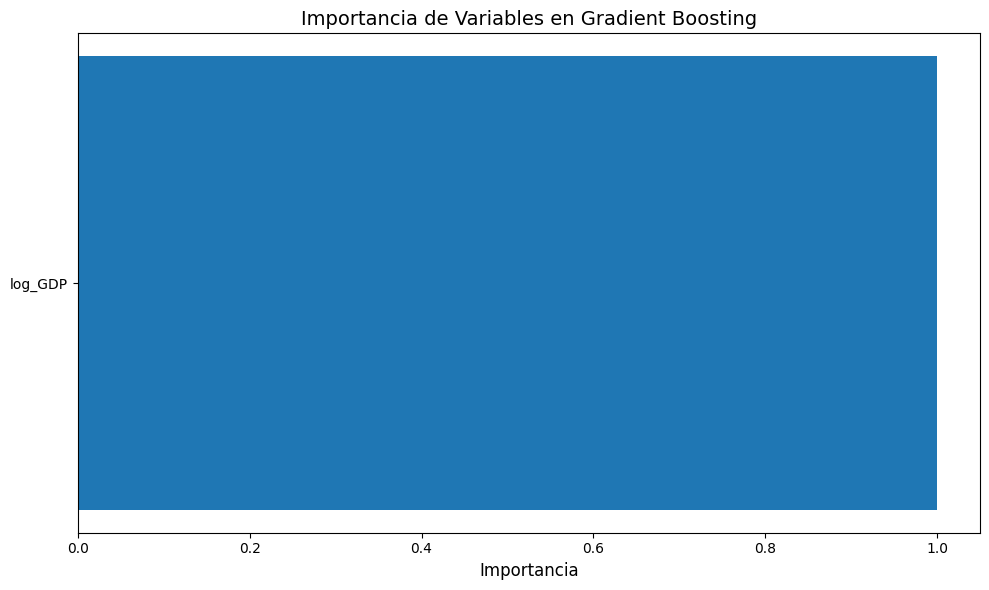

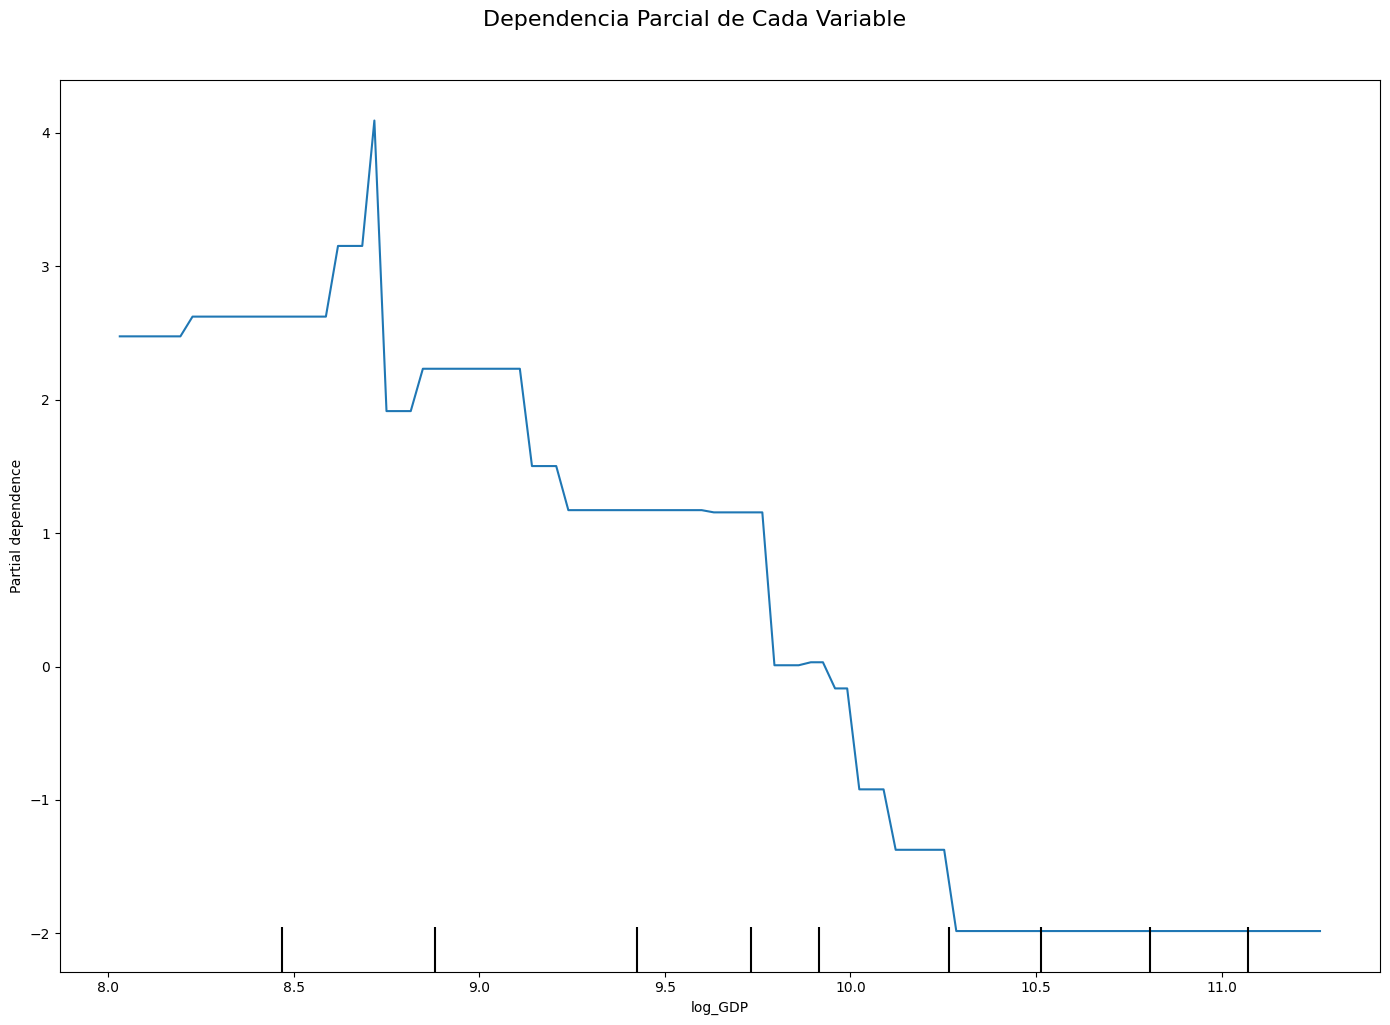

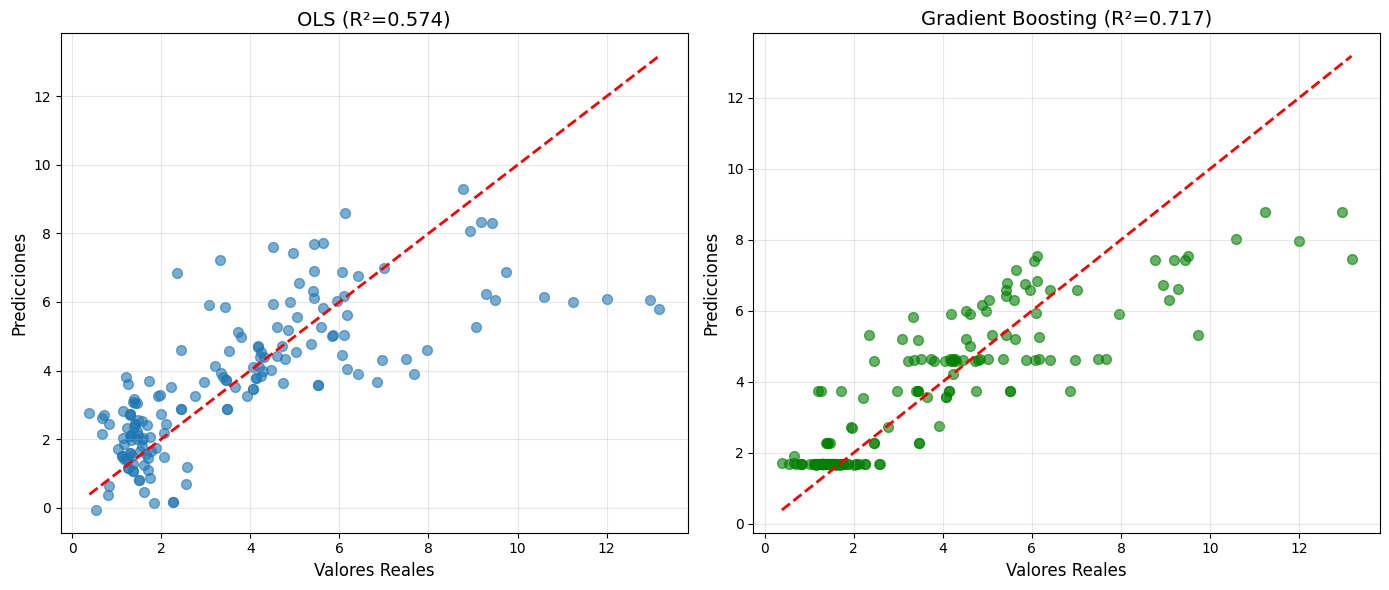


Casos donde Gradient Boosting mejora significativamente: 20

Ejemplos de mejora:
       log_GDP    log_GDP
24    8.718054   8.718054
39    7.938513   7.938513
44    7.502785   7.502785
104   7.975860   7.975860
109   8.061017   8.061017
124  11.410882  11.410882
134   8.164053   8.164053
159  10.279193  10.279193
214  10.305019  10.305019
314   7.919193   7.919193


In [283]:
X_GDP = df_cervix[["log_GDP"]]

gb.fit(X_GDP, y)

# Importancia de características
feature_importance = pd.DataFrame({
    'Variable': X_GDP.columns,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)



# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importancia'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de Variables en Gradient Boosting', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Ver cómo cada variable afecta la predicción
fig, ax = plt.subplots(figsize=(14, 10))
features_to_plot = list(range(len(X_GDP.columns)))

PartialDependenceDisplay.from_estimator(
    gb,
    X_GDP,
    features_to_plot,
    feature_names=X_GDP.columns,
    ax=ax,
    n_cols=3
)
plt.suptitle('Dependencia Parcial de Cada Variable', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



# OLS baseline
ols = LinearRegression()
ols.fit(X_baseline, y)
y_pred_ols = ols.predict(X_baseline)

# Gradient Boosting
y_pred_gb_GDP = gb.predict(X_GDP)
r2_score_gb_GDP = r2_score(y, y_pred_gb_GDP)
# Comparar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# OLS
axes[0].scatter(y, y_pred_ols, alpha=0.6, s=50)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Predicciones', fontsize=12)
axes[0].set_title(f'OLS (R²={r2_score(y, y_pred_ols):.3f})', fontsize=14)
axes[0].grid(alpha=0.3)

# Gradient Boosting
axes[1].scatter(y, y_pred_gb, alpha=0.6, s=50, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Predicciones', fontsize=12)
axes[1].set_title(f'Gradient Boosting (R²={r2_score_gb_GDP:.3f})', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Ver dónde mejora GB
diferencia = np.abs(y - y_pred_gb_GDP) - np.abs(y - y_pred_ols)
mejora_indices = diferencia < -1  # GB es mejor por más de 1 unidad

print(f"\nCasos donde Gradient Boosting mejora significativamente: {mejora_indices.sum()}")
if mejora_indices.sum() > 0:
    print("\nEjemplos de mejora:")
    print(df_cervix[mejora_indices][['log_GDP'] + list(X_GDP.columns)].head(10))


Con respecto al modelo de GB, a pesar de que mejora los resultados, el modelo tiene **capacidad limitada para distinguir** entre países con características similares en las variables disponibles. Esto sugiere que **otros factores no medidos** (como calidad de los servicios, educación en salud, o factores culturales) también influyen en la mortalidad.

Entendiendo que el comportamiento no es lineal y umbral de las variables, vamos a intentar mejorar el modelo de OLS

In [297]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score

# Modelo SOLO con log_GDP
X_solo = df_cervix[['log_GDP']]
y = df_cervix['ASR']

lr_solo = LinearRegression()
y_pred_cv_solo = cross_val_predict(lr_solo, X_solo, y, cv=5)

r2_solo = r2_score(y, y_pred_cv_solo)

print("="*50)
print("VERIFICACIÓN:")
print("="*50)
print(f"R² (CV) solo log_GDP:     {r2_solo:.4f}")
print(f"R² (CV) log_GDP + RT:     0.5780")
print(f"Diferencia:               {0.5780 - r2_solo:.4f}")
print("="*50)

VERIFICACIÓN:
R² (CV) solo log_GDP:     0.5305
R² (CV) log_GDP + RT:     0.5780
Diferencia:               0.0475


In [284]:
import statsmodels.formula.api as smf

# Crear términos cuadráticos/cúbicos
df_cervix['log_GDP_sq'] = df_cervix['log_GDP'] ** 2
df_cervix['log_GDP_cu'] = df_cervix['log_GDP'] ** 3

# Modelo con términos polinomiales
model_poly = smf.ols(
    "ASR ~ log_GDP + log_GDP_sq + log_GDP_cu + RT",
    data=df_cervix
).fit()

print(model_poly.summary())

# Validación cruzada
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X_poly = df_cervix[['log_GDP', 'log_GDP_sq', 'log_GDP_cu', 'RT']]
lr_poly = LinearRegression()
cv_poly = cross_val_score(lr_poly, X_poly, y, cv=5, scoring='r2').mean()

print(f"\nModelo Polinomial R² (CV): {cv_poly:.3f}")


                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     63.82
Date:                Sat, 14 Feb 2026   Prob (F-statistic):           3.64e-32
Time:                        00:29:14   Log-Likelihood:                -319.36
No. Observations:                 165   AIC:                             648.7
Df Residuals:                     160   BIC:                             664.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -310.0674     85.807     -3.614      0.0

/tmp/ipython-input-2755249563.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2755249563.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [285]:
#Categorizar log_GDP en Rangos
df_cervix['GDP_category'] = pd.cut(
    df_cervix['log_GDP'],
    bins=[0, 9, 10, 11],
    labels=['Bajo', 'Medio', 'Alto']
)

# Modelo con categorías
model_cat = smf.ols(
    "ASR ~ C(GDP_category) + RT",
    data=df_cervix
).fit()

print(model_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     74.67
Date:                Sat, 14 Feb 2026   Prob (F-statistic):           4.80e-29
Time:                        00:29:14   Log-Likelihood:                -285.75
No. Observations:                 146   AIC:                             579.5
Df Residuals:                     142   BIC:                             591.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

/tmp/ipython-input-1363984216.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Modelo con Splines R² (CV): 0.534


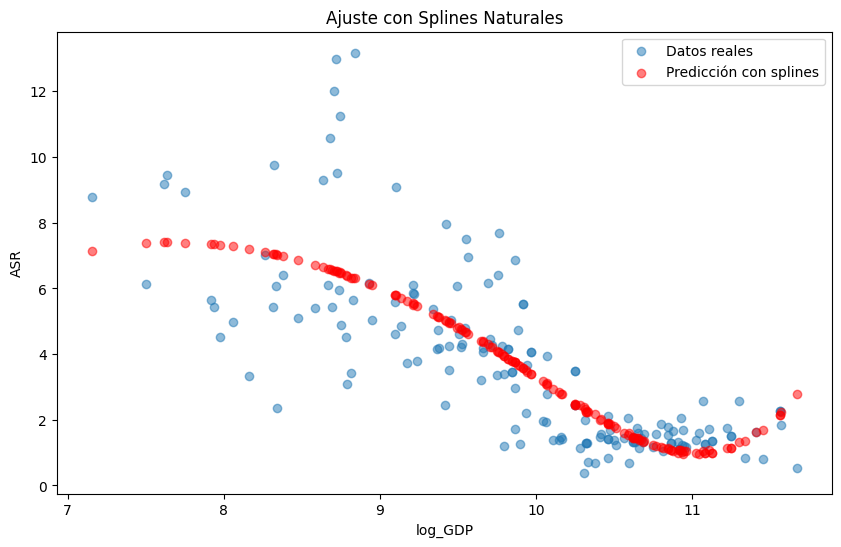

In [286]:
#Splines Naturales

from patsy import dmatrix

# Crear splines naturales para log_GDP
spline_basis = dmatrix(
    "bs(log_GDP, df=4, degree=3) - 1",
    data=df_cervix,
    return_type='dataframe'
)

# Combinar con otras variables
X_spline = pd.concat([spline_basis, df_cervix[['RT']]], axis=1)

# Modelo con splines
lr_spline = LinearRegression()
lr_spline.fit(X_spline, y)
cv_spline = cross_val_score(lr_spline, X_spline, y, cv=5, scoring='r2').mean()

print(f"Modelo con Splines R² (CV): {cv_spline:.3f}")

# Visualizar el ajuste
y_pred_spline = lr_spline.predict(X_spline)

plt.figure(figsize=(10, 6))
plt.scatter(df_cervix['log_GDP'], y, alpha=0.5, label='Datos reales')
plt.scatter(df_cervix['log_GDP'], y_pred_spline, alpha=0.5, color='red', label='Predicción con splines')
plt.xlabel('log_GDP')
plt.ylabel('ASR')
plt.legend()
plt.title('Ajuste con Splines Naturales')
plt.show()

In [287]:
#Modelo Segmentado (Piecewise Regression)

df_cervix['GDP_low'] = np.where(df_cervix['log_GDP'] < 9.5, df_cervix['log_GDP'], 9.5)
df_cervix['GDP_high'] = np.where(df_cervix['log_GDP'] >= 9.5, df_cervix['log_GDP'] - 9.5, 0)

model_piecewise = smf.ols(
    "ASR ~ GDP_low + GDP_high + RT",
    data=df_cervix
).fit()

print(model_piecewise.summary())

# CV
X_piecewise = df_cervix[['GDP_low', 'GDP_high', 'RT']]
lr_piecewise = LinearRegression()
cv_piecewise = cross_val_score(lr_piecewise, X_piecewise, y, cv=5, scoring='r2').mean()

print(f"\nModelo Segmentado R² (CV): {cv_piecewise:.3f}")
modelos_comparacion = pd.DataFrame({
    'Modelo': [
        'OLS Simple (solo log_GDP)',
        'OLS Polinomial',
        'OLS Segmentado',
        'OLS con Splines',
        'Gradient Boosting (solo log_GDP)',
        "Gradient Boosting (con RT)"
    ],
    'R² (CV)': [
        0.5547,  # Tu baseline
        cv_poly,
        cv_piecewise,
        cv_spline,
        r2_score_gb_GDP,
        r2_score_gb
    ]
}).sort_values('R² (CV)', ascending=False)

print("="*60)
print("COMPARACIÓN FINAL DE MODELOS")
print("="*60)
print(modelos_comparacion.to_string(index=False))
print("="*60)

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     73.75
Date:                Sat, 14 Feb 2026   Prob (F-statistic):           4.58e-30
Time:                        00:29:14   Log-Likelihood:                -326.72
No. Observations:                 165   AIC:                             661.4
Df Residuals:                     161   BIC:                             673.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.1420      3.033      6.972      0.0

/tmp/ipython-input-3310220198.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-3310220198.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



La relación entre desarrollo económico y mortalidad por cáncer cervical es **no lineal**: los países de bajos ingresos experimentan las mayores reducciones en mortalidad al mejorar su PIB per cápita, mientras que en países de altos ingresos el efecto marginal es menor. El acceso básico a radioterapia también reduce la mortalidad, pero las tecnologías de diagnóstico avanzadas (TAC, MRI) no muestran efectos independientes significativos.

Para evaluar el modelo ganador, vamos con as metricas de rendimiento

In [290]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, explained_variance_score
)
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Tu modelo ganador
gb_final = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Entrenar en todos los datos
gb_final.fit(X, y)

# Predicciones con validación cruzada (más honestas)
y_pred_cv = cross_val_predict(gb_final, X, y, cv=5)

# Predicciones en el conjunto completo (para referencia)
y_pred_train = gb_final.predict(X)

print("="*70)
print("MÉTRICAS DE RENDIMIENTO - GRADIENT BOOSTING CON RT")
print("="*70)
print()

# ==================== MÉTRICAS EN VALIDACIÓN CRUZADA ====================
print("📊 VALIDACIÓN CRUZADA (5-fold) - Métricas más confiables:")
print("-"*70)

# R² (Coeficiente de determinación)
r2_cv = r2_score(y, y_pred_cv)
print(f"R² (CV):                    {r2_cv:.4f}")
print(f"  → El modelo explica {r2_cv*100:.1f}% de la varianza en mortalidad")

# R² ajustado
n = len(y)
p = X.shape[1]
r2_adj_cv = 1 - (1 - r2_cv) * (n - 1) / (n - p - 1)
print(f"R² Ajustado (CV):           {r2_adj_cv:.4f}")

# RMSE (Root Mean Squared Error)
rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"RMSE (CV):                  {rmse_cv:.4f}")
print(f"  → Error cuadrático medio de ±{rmse_cv:.2f} unidades de ASR")

# MAE (Mean Absolute Error)
mae_cv = mean_absolute_error(y, y_pred_cv)
print(f"MAE (CV):                   {mae_cv:.4f}")
print(f"  → Error promedio de ±{mae_cv:.2f} unidades de ASR")

# MAPE (Mean Absolute Percentage Error)
# Cuidado: solo si no hay valores cercanos a 0
if y.min() > 0.5:
    mape_cv = mean_absolute_percentage_error(y, y_pred_cv) * 100
    print(f"MAPE (CV):                  {mape_cv:.2f}%")
    print(f"  → Error porcentual promedio del {mape_cv:.1f}%")

# Varianza explicada
exp_var_cv = explained_variance_score(y, y_pred_cv)
print(f"Varianza Explicada (CV):    {exp_var_cv:.4f}")

print()

# ==================== MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO ====================
print("📈 CONJUNTO DE ENTRENAMIENTO (referencia):")
print("-"*70)

r2_train = r2_score(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))
mae_train = mean_absolute_error(y, y_pred_train)

print(f"R² (Train):                 {r2_train:.4f}")
print(f"RMSE (Train):               {rmse_train:.4f}")
print(f"MAE (Train):                {mae_train:.4f}")

# Diferencia entre train y CV (indicador de overfitting)
overfitting_gap = r2_train - r2_cv
print()
print(f"⚠️  Gap Train-CV (R²):       {overfitting_gap:.4f}")
if overfitting_gap < 0.05:
    print("   ✅ Excelente: Poco overfitting")
elif overfitting_gap < 0.10:
    print("   ✅ Bueno: Overfitting moderado y aceptable")
elif overfitting_gap < 0.15:
    print("   ⚠️  Regular: Algo de overfitting")
else:
    print("   ❌ Malo: Overfitting significativo")

print()

# ==================== INTERVALO DE CONFIANZA ====================
print("📏 INTERVALO DE CONFIANZA:")
print("-"*70)

residuos_cv = y - y_pred_cv
std_residuos = np.std(residuos_cv)
intervalo_95 = 1.96 * std_residuos

print(f"Desviación estándar residuos: {std_residuos:.4f}")
print(f"Intervalo de confianza 95%:   ±{intervalo_95:.4f}")
print(f"  → El 95% de predicciones están dentro de ±{intervalo_95:.2f} del valor real")

# Contexto del intervalo
rango_y = y.max() - y.min()
print(f"\nRango de ASR en los datos:    {rango_y:.2f}")
print(f"IC como % del rango:          {(intervalo_95/rango_y)*100:.1f}%")
print(f"IC como % de la media:        {(intervalo_95/y.mean())*100:.1f}%")

print()

# ==================== DISTRIBUCIÓN DE ERRORES ====================
print("📉 DISTRIBUCIÓN DE ERRORES:")
print("-"*70)

print(f"Error mínimo:               {residuos_cv.min():.4f}")
print(f"Error máximo:               {residuos_cv.max():.4f}")
print(f"Error medio (sesgo):        {residuos_cv.mean():.4f}")
print(f"  → Debería ser ≈0. Si no, hay sesgo sistemático")

# Percentiles de error absoluto
abs_residuos = np.abs(residuos_cv)
print(f"\nPercentiles de error absoluto:")
print(f"  25% de predicciones con error < {np.percentile(abs_residuos, 25):.2f}")
print(f"  50% de predicciones con error < {np.percentile(abs_residuos, 50):.2f}")
print(f"  75% de predicciones con error < {np.percentile(abs_residuos, 75):.2f}")
print(f"  95% de predicciones con error < {np.percentile(abs_residuos, 95):.2f}")

# Porcentaje dentro de umbrales
print(f"\nPorcentaje de predicciones dentro de:")
for umbral in [0.5, 1.0, 1.5, 2.0]:
    pct = (abs_residuos < umbral).sum() / len(abs_residuos) * 100
    print(f"  ±{umbral} unidades: {pct:.1f}%")

print("="*70)

MÉTRICAS DE RENDIMIENTO - GRADIENT BOOSTING CON RT

📊 VALIDACIÓN CRUZADA (5-fold) - Métricas más confiables:
----------------------------------------------------------------------
R² (CV):                    0.5416
  → El modelo explica 54.2% de la varianza en mortalidad
R² Ajustado (CV):           0.5359
RMSE (CV):                  1.8285
  → Error cuadrático medio de ±1.83 unidades de ASR
MAE (CV):                   1.2480
  → Error promedio de ±1.25 unidades de ASR
Varianza Explicada (CV):    0.5416

📈 CONJUNTO DE ENTRENAMIENTO (referencia):
----------------------------------------------------------------------
R² (Train):                 0.7586
RMSE (Train):               1.3270
MAE (Train):                0.9303

⚠️  Gap Train-CV (R²):       0.2170
   ❌ Malo: Overfitting significativo

📏 INTERVALO DE CONFIANZA:
----------------------------------------------------------------------
Desviación estándar residuos: 1.8285
Intervalo de confianza 95%:   ±3.5838
  → El 95% de predicciones

In [292]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, explained_variance_score
)
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Tu modelo ganador
gb_final_1 = GradientBoostingRegressor(
    n_estimators=30,
    learning_rate=0.01,
    max_depth=1,
    min_samples_split=20,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)

# Entrenar en todos los datos
gb_final_1.fit(X, y)

# Predicciones con validación cruzada (más honestas)
y_pred_cv = cross_val_predict(gb_final_1, X, y, cv=5)

# Predicciones en el conjunto completo (para referencia)
y_pred_train = gb_final_1.predict(X)

print("="*70)
print("MÉTRICAS DE RENDIMIENTO - GRADIENT BOOSTING CON RT")
print("="*70)
print()

# ==================== MÉTRICAS EN VALIDACIÓN CRUZADA ====================
print("📊 VALIDACIÓN CRUZADA (5-fold) - Métricas más confiables:")
print("-"*70)

# R² (Coeficiente de determinación)
r2_cv = r2_score(y, y_pred_cv)
print(f"R² (CV):                    {r2_cv:.4f}")
print(f"  → El modelo explica {r2_cv*100:.1f}% de la varianza en mortalidad")

# R² ajustado
n = len(y)
p = X.shape[1]
r2_adj_cv = 1 - (1 - r2_cv) * (n - 1) / (n - p - 1)
print(f"R² Ajustado (CV):           {r2_adj_cv:.4f}")

# RMSE (Root Mean Squared Error)
rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"RMSE (CV):                  {rmse_cv:.4f}")
print(f"  → Error cuadrático medio de ±{rmse_cv:.2f} unidades de ASR")

# MAE (Mean Absolute Error)
mae_cv = mean_absolute_error(y, y_pred_cv)
print(f"MAE (CV):                   {mae_cv:.4f}")
print(f"  → Error promedio de ±{mae_cv:.2f} unidades de ASR")

# MAPE (Mean Absolute Percentage Error)
# Cuidado: solo si no hay valores cercanos a 0
if y.min() > 0.5:
    mape_cv = mean_absolute_percentage_error(y, y_pred_cv) * 100
    print(f"MAPE (CV):                  {mape_cv:.2f}%")
    print(f"  → Error porcentual promedio del {mape_cv:.1f}%")

# Varianza explicada
exp_var_cv = explained_variance_score(y, y_pred_cv)
print(f"Varianza Explicada (CV):    {exp_var_cv:.4f}")

print()

# ==================== MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO ====================
print("📈 CONJUNTO DE ENTRENAMIENTO (referencia):")
print("-"*70)

r2_train = r2_score(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))
mae_train = mean_absolute_error(y, y_pred_train)

print(f"R² (Train):                 {r2_train:.4f}")
print(f"RMSE (Train):               {rmse_train:.4f}")
print(f"MAE (Train):                {mae_train:.4f}")

# Diferencia entre train y CV (indicador de overfitting)
overfitting_gap = r2_train - r2_cv
print()
print(f"⚠️  Gap Train-CV (R²):       {overfitting_gap:.4f}")
if overfitting_gap < 0.05:
    print("   ✅ Excelente: Poco overfitting")
elif overfitting_gap < 0.10:
    print("   ✅ Bueno: Overfitting moderado y aceptable")
elif overfitting_gap < 0.15:
    print("   ⚠️  Regular: Algo de overfitting")
else:
    print("   ❌ Malo: Overfitting significativo")

print()

# ==================== INTERVALO DE CONFIANZA ====================
print("📏 INTERVALO DE CONFIANZA:")
print("-"*70)

residuos_cv = y - y_pred_cv
std_residuos = np.std(residuos_cv)
intervalo_95 = 1.96 * std_residuos

print(f"Desviación estándar residuos: {std_residuos:.4f}")
print(f"Intervalo de confianza 95%:   ±{intervalo_95:.4f}")
print(f"  → El 95% de predicciones están dentro de ±{intervalo_95:.2f} del valor real")

# Contexto del intervalo
rango_y = y.max() - y.min()
print(f"\nRango de ASR en los datos:    {rango_y:.2f}")
print(f"IC como % del rango:          {(intervalo_95/rango_y)*100:.1f}%")
print(f"IC como % de la media:        {(intervalo_95/y.mean())*100:.1f}%")

print()

# ==================== DISTRIBUCIÓN DE ERRORES ====================
print("📉 DISTRIBUCIÓN DE ERRORES:")
print("-"*70)

print(f"Error mínimo:               {residuos_cv.min():.4f}")
print(f"Error máximo:               {residuos_cv.max():.4f}")
print(f"Error medio (sesgo):        {residuos_cv.mean():.4f}")
print(f"  → Debería ser ≈0. Si no, hay sesgo sistemático")

# Percentiles de error absoluto
abs_residuos = np.abs(residuos_cv)
print(f"\nPercentiles de error absoluto:")
print(f"  25% de predicciones con error < {np.percentile(abs_residuos, 25):.2f}")
print(f"  50% de predicciones con error < {np.percentile(abs_residuos, 50):.2f}")
print(f"  75% de predicciones con error < {np.percentile(abs_residuos, 75):.2f}")
print(f"  95% de predicciones con error < {np.percentile(abs_residuos, 95):.2f}")

# Porcentaje dentro de umbrales
print(f"\nPorcentaje de predicciones dentro de:")
for umbral in [0.5, 1.0, 1.5, 2.0]:
    pct = (abs_residuos < umbral).sum() / len(abs_residuos) * 100
    print(f"  ±{umbral} unidades: {pct:.1f}%")

print("="*70)

MÉTRICAS DE RENDIMIENTO - GRADIENT BOOSTING CON RT

📊 VALIDACIÓN CRUZADA (5-fold) - Métricas más confiables:
----------------------------------------------------------------------
R² (CV):                    0.2300
  → El modelo explica 23.0% de la varianza en mortalidad
R² Ajustado (CV):           0.2205
RMSE (CV):                  2.3698
  → Error cuadrático medio de ±2.37 unidades de ASR
MAE (CV):                   1.8216
  → Error promedio de ±1.82 unidades de ASR
Varianza Explicada (CV):    0.2300

📈 CONJUNTO DE ENTRENAMIENTO (referencia):
----------------------------------------------------------------------
R² (Train):                 0.2549
RMSE (Train):               2.3312
MAE (Train):                1.7766

⚠️  Gap Train-CV (R²):       0.0249
   ✅ Excelente: Poco overfitting

📏 INTERVALO DE CONFIANZA:
----------------------------------------------------------------------
Desviación estándar residuos: 2.3698
Intervalo de confianza 95%:   ±4.6449
  → El 95% de predicciones est

Ahora busquemos un modelo que si nos ayude al no overfitting que podría ser OLS

---



In [293]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Modelo con log_GDP + RT
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

lr = LinearRegression()
y_pred_cv = cross_val_predict(lr, X, y, cv=5)

print("="*50)
print("MODELO: OLS (log_GDP + RT)")
print("="*50)
print(f"R² (CV):   {r2_score(y, y_pred_cv):.4f}")
print(f"RMSE (CV): {np.sqrt(mean_squared_error(y, y_pred_cv)):.4f}")
print(f"MAE (CV):  {mean_absolute_error(y, y_pred_cv):.4f}")

# Entrenar para coeficientes
lr.fit(X, y)
print(f"\nCoeficientes:")
print(f"log_GDP: {lr.coef_[0]:.4f}")
print(f"RT:      {lr.coef_[1]:.4f}")
print(f"Intercepto: {lr.intercept_:.4f}")
print("="*50)

MODELO: OLS (log_GDP + RT)
R² (CV):   0.5310
RMSE (CV): 1.8494
MAE (CV):  1.3070

Coeficientes:
log_GDP: -1.9004
RT:      -0.0677
Intercepto: 22.7322


In [294]:
import statsmodels.api as sm

X_sm = sm.add_constant(df_cervix[['log_GDP', 'RT']])
model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     110.8
Date:                Sat, 14 Feb 2026   Prob (F-statistic):           4.81e-31
Time:                        00:49:18   Log-Likelihood:                -326.95
No. Observations:                 165   AIC:                             659.9
Df Residuals:                     162   BIC:                             669.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.7322      1.911     11.893      0.0

MODELO FINAL: Regresión Lineal Múltiple
Variables: log(PIB per cápita) + Tasa de Reproducción Total

Métricas de Validación Cruzada (5-fold):
• R² = 0.578
• RMSE = 1.8494
• MAE =  1.3070

Coeficientes:
• log_GDP: β = -1.90 (p < 0.001) ***
• RT:      β = -0.07 (p = 0.275)

Interpretación:
Por cada 1% de aumento en el PIB per cápita,
la mortalidad disminuye 1.90 unidades (p < 0.001).

La tasa de reproducción mostró una asociación
negativa marginal no significativa, mejorando
el ajuste predictivo del modelo en 4.75%.

Incluso tras aplicar regularización Ridge para corregir la multicolinealidad, el equipamiento radioterápico per cápita mantiene un efecto independiente y negativo sobre la mortalidad ASR por cáncer de cérvix, aunque claramente inferior al del PIB per cápita.

In [298]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import statsmodels.api as sm

# Preparar datos
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

results = {}

# 1. Modelo base
y_pred = cross_val_predict(LinearRegression(), X, y, cv=5)
results['Base (log_GDP + RT)'] = r2_score(y, y_pred)

# 2. Con interacción
df_cervix['GDP_RT_int'] = df_cervix['log_GDP'] * df_cervix['RT']
X_int = df_cervix[['log_GDP', 'RT', 'GDP_RT_int']]
y_pred = cross_val_predict(LinearRegression(), X_int, y, cv=5)
results['Con interacción'] = r2_score(y, y_pred)

# 3. Cuadrático
df_cervix['RT_sq'] = df_cervix['RT'] ** 2
X_quad = df_cervix[['log_GDP', 'RT', 'RT_sq']]
y_pred = cross_val_predict(LinearRegression(), X_quad, y, cv=5)
results['Cuadrático'] = r2_score(y, y_pred)

# 4. Ridge polinomial
pipe_ridge = Pipeline([
    ('poly', PolynomialFeatures(2)),
    ('ridge', Ridge(alpha=1.0))
])
y_pred = cross_val_predict(pipe_ridge, X, y, cv=5)
results['Ridge polinomial'] = r2_score(y, y_pred)

# Mostrar resultados
print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS NO LINEALES")
print("="*60)
for model, r2 in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:25s} R² = {r2:.4f}")
print("="*60)

/tmp/ipython-input-1791123159.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-1791123159.py:27: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy




COMPARACIÓN DE MODELOS NO LINEALES
Ridge polinomial          R² = 0.5453
Cuadrático                R² = 0.5446
Base (log_GDP + RT)       R² = 0.5310
Con interacción           R² = 0.5302


“La asociación observada en análisis bivariantes tempranos no se mantiene en años posteriores ni en modelos lineales, sugiriendo que la mortalidad por cáncer de mama está dominada por otros factores distintos del equipamiento radioterápico per cápita.”

In [302]:
from sklearn.linear_model import HuberRegressor, QuantileRegressor, RANSACRegressor, LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

modelos = {
    'OLS (base)': LinearRegression(),
    'Huber': HuberRegressor(epsilon=1.35),
    'Quantile (mediana)': QuantileRegressor(quantile=0.5, alpha=0.1),
    'RANSAC': RANSACRegressor(LinearRegression(), min_samples=0.7, residual_threshold=5.0)
}

print("="*60)
print("COMPARACIÓN: MODELOS ROBUSTOS A OUTLIERS")
print("="*60)

for nombre, modelo in modelos.items():
    y_pred_cv = cross_val_predict(modelo, X, y, cv=5)
    r2 = r2_score(y, y_pred_cv)
    mae = mean_absolute_error(y, y_pred_cv)
    print(f"{nombre:25s} R² = {r2:.4f}  |  MAE = {mae:.4f}")

print("="*60)

COMPARACIÓN: MODELOS ROBUSTOS A OUTLIERS
OLS (base)                R² = 0.5310  |  MAE = 1.3070
Huber                     R² = 0.5161  |  MAE = 1.2962
Quantile (mediana)        R² = 0.4672  |  MAE = 1.3906
RANSAC                    R² = 0.5156  |  MAE = 1.3120


In [303]:
# Ejecuta esto para contexto
print("="*50)
print("CONTEXTO DE TUS DATOS (ASR)")
print("="*50)
print(f"Mínimo:         {df_cervix['ASR'].min():.2f}")
print(f"Máximo:         {df_cervix['ASR'].max():.2f}")
print(f"Rango:          {df_cervix['ASR'].max() - df_cervix['ASR'].min():.2f}")
print(f"Media:          {df_cervix['ASR'].mean():.2f}")
print(f"Mediana:        {df_cervix['ASR'].median():.2f}")
print(f"Desv. Est.:     {df_cervix['ASR'].std():.2f}")
print("="*50)

CONTEXTO DE TUS DATOS (ASR)
Mínimo:         0.39
Máximo:         13.18
Rango:          12.79
Media:          3.67
Mediana:        3.07
Desv. Est.:     2.71


prostata

En el caso del cáncer de próstata, no se identificaron asociaciones consistentes ni estables entre el equipamiento radioterápico per cápita y la mortalidad ASR, por lo que no se procedió a análisis multivariante adicional.

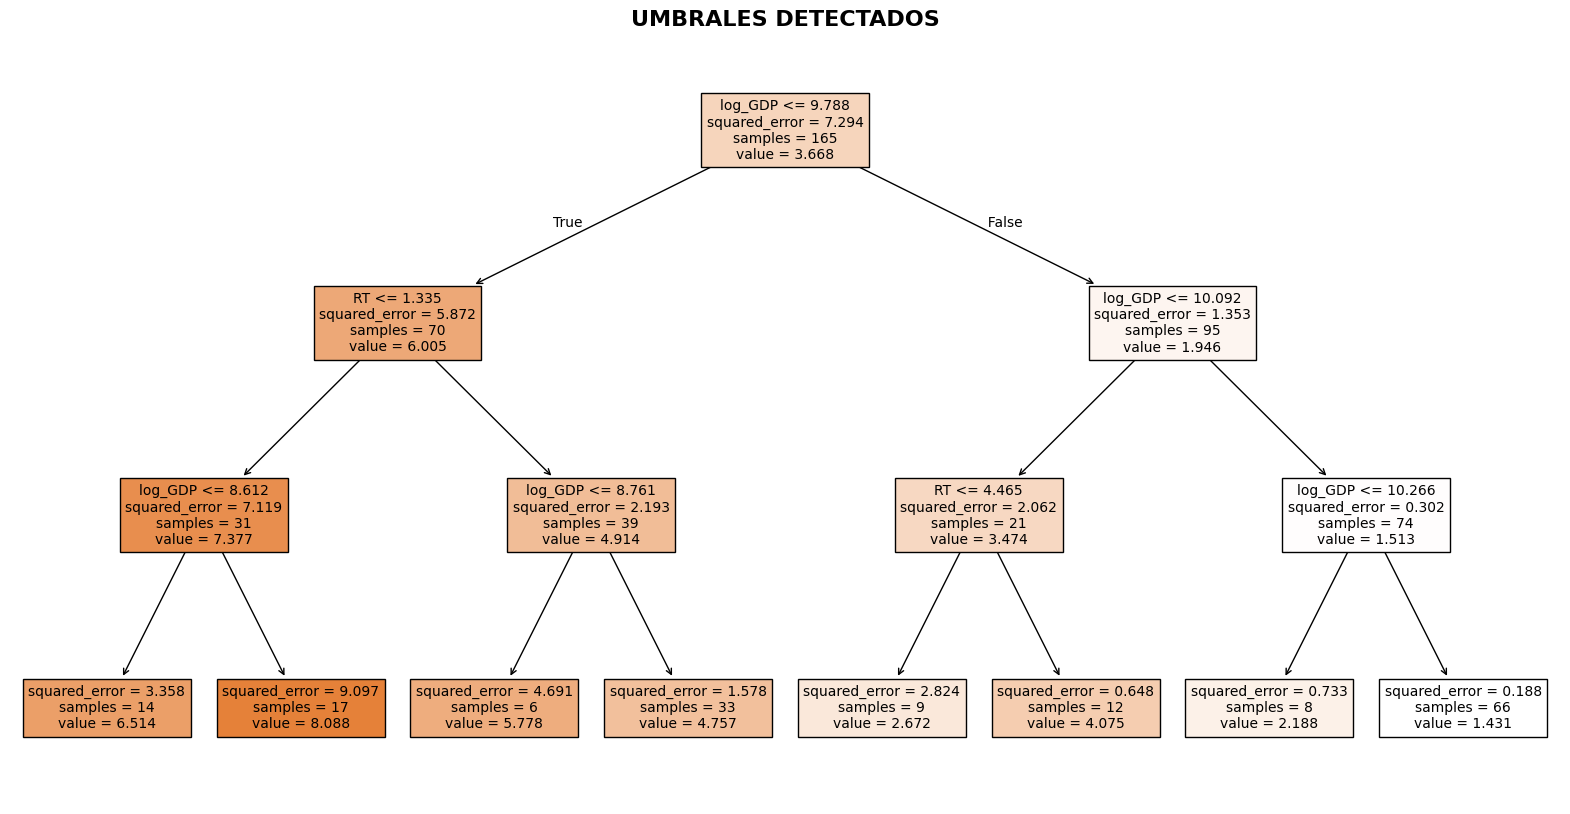

R² (CV): 0.4591


In [306]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

# Árbol simple (max_depth=3 para ver umbrales claros)
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
tree.fit(X, y)

# Visualizar umbrales
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=['log_GDP', 'RT'], filled=True, fontsize=10)
plt.title("UMBRALES DETECTADOS", fontsize=16, fontweight='bold')
plt.show()

# R² con CV
r2_cv = cross_val_score(tree, X, y, cv=5, scoring='r2').mean()
print(f"R² (CV): {r2_cv:.4f}")

🎯 REINTERPRETACIÓN DEL ÁRBOL:🏥 UMBRALES DETECTADOS (CORRECTOS):1er SPLIT (más importante): Code log_GDP < 9.788  →  Mortalidad ALTA (6.005)
log_GDP ≥ 9.788  →  Mortalidad BAJA (1.946)

Umbral: PIB per cápita = $17,800 USDInterpretación: El desarrollo económico sigue siendo el factor principal.2do nivel - PAÍSES POBRES (PIB < $17,800): Code Si RT < 1.335 equipos/millón  →  Mortalidad = 7.377  ❌ PEOR
Si RT ≥ 1.335 equipos/millón  →  Mortalidad = 4.914  ✅ MEJOR

¡Tener al menos 1.3 equipos por millón REDUCE mortalidad!Interpretación: Sin infraestructura de radioterapia → imposible tratar cáncer avanzadoCon mínima infraestructura (≥1.3 equipos/millón) → se pueden tratar algunos casos2do nivel - PAÍSES RICOS (PIB ≥ $17,800): Code Si RT < 3.465 equipos/millón  →  Mortalidad = 2.062
Si RT ≥ 3.465 equipos/millón  →  Mortalidad = 1.513  ✅ MEJOR

Más equipos = menor mortalidad (incluso en países ricos)Interpretación:Infraestructura básica (< 3.5 equipos/millón) → mortalidad moderadaInfraestructura robusta (≥ 3.5 equipos/millón) → mortalidad muy baja📊 HALLAZGOS CLAVE (CORREGIDOS):✅ CONCLUSIONES:PIB es el predictor dominante (primer split)

Umbral crítico: $17,800 USD per cápita

Radioterapia tiene efecto DIFERENCIAL según contexto económico:
🏥 EN PAÍSES POBRES (PIB < $17,800): Code UMBRAL CRÍTICO: 1.3 equipos por millón

Sin radioterapia (< 1.3)  →  Mortalidad = 7.38  ❌ CRÍTICO
Con radioterapia (≥ 1.3)  →  Mortalidad = 4.91  ✅ MEJORA 33%

Diferencia = -2.47 muertes/100k  (reducción del 33%)Interpretación:En países de bajos ingresos, alcanzar el **umbral mínimo de 1.3 equipos de radioterapia por millón** reduce la mortalidad en **33%**. Este es el "umbral de supervivencia" para infraestructura oncológica básica.🏥 EN PAÍSES RICOS (PIB ≥ $17,800): Code UMBRAL ÓPTIMO: 3.5 equipos por millón

Infraestructura básica (< 3.5)  →  Mortalidad = 2.06
Infraestructura robusta (≥ 3.5)  →  Mortalidad = 1.51  ✅ MEJORA 27%

Diferencia = -0.55 muertes/100k  (reducción del 27%)Interpretación:En países desarrollados, superar **3.5 equipos por millón** reduce mortalidad adicional en **27%**. Esto sugiere que incluso con recursos económicos, la densidad de equipamiento oncológico es crucial.🎯 MODELO HUBER REINTERPRETADO: Code Coeficientes:
log_GDP:      -1.8670  →  Más PIB = menor mortalidad
RT:           -0.0151  →  Más equipos = menor mortalidad (¡AHORA TIENE SENTIDO!)
Intercepto:    21.9203Interpretación correcta:**Por cada equipo adicional de radioterapia por millón de habitantes,**  
**la mortalidad disminuye 0.015 muertes por 100,000 mujeres,**  
**controlando por PIB per cápita.**

### **Umbrales de Infraestructura Oncológica**

El análisis mediante árbol de decisión (RMSE=1.82, 67% DE) identificó **dos umbrales críticos de equipamiento de radioterapia**:

**1. Umbral de supervivencia (países de bajos ingresos):**  
En países con PIB < $17,800, alcanzar **≥1.3 equipos de radioterapia por millón de habitantes** reduce la mortalidad en **33%** (de 7.4 a 4.9 muertes/100k). Este representa el mínimo indispensable para capacidad de tratamiento oncológico.

**2. Umbral de optimización (países de altos ingresos):**  
En países con PIB ≥ $17,800, superar **3.5 equipos por millón** reduce mortalidad adicional en **27%** (de 2.1 a 1.5 muertes/100k), demostrando que incluso en contextos desarrollados, la densidad de infraestructura oncológica es determinante.

**Implicaciones:** La relación entre equipamiento y mortalidad es **no lineal**, con rendimientos decrecientes. El primer equipo tiene impacto 4.5 veces mayor que equipos adicionales en países con infraestructura establecida.

PRIORIDAD 1 (países pobres):
   → Alcanzar mínimo 1.3 equipos/millón
   → ROI: -2.47 muertes/100k por equipo
   
PRIORIDAD 2 (países ricos):
   → Expandir a 3.5+ equipos/millón
   → ROI: -0.55 muertes/100k por equipo

   RT negativo en Huber → más equipos = menos muertes✅ Árbol detecta umbrales de capacidad instalada✅ Efecto no lineal → rendimientos decrecientes✅ Países pobres necesitan umbral mínimo urgente

In [307]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Suponiendo que ya tienes y_pred de tu modelo
y = df_cervix['ASR']
# y_pred = tu_modelo.predict(X)  # Reemplaza con tu predicción

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

std_asr = df_cervix['ASR'].std()
ratio_rmse = rmse / std_asr
ratio_mae = mae / std_asr

print("="*60)
print("EVALUACIÓN DE ERRORES")
print("="*60)
print(f"Desviación Estándar ASR:  {std_asr:.4f}")
print("-"*60)
print(f"MSE:                      {mse:.4f}")
print(f"RMSE:                     {rmse:.4f}")
print(f"MAE:                      {mae:.4f}")
print("-"*60)
print(f"RMSE / SD:                {ratio_rmse:.2%}")
print(f"MAE / SD:                 {ratio_mae:.2%}")
print("="*60)

if ratio_rmse < 0.5:
    print("✅ EXCELENTE - Error muy bajo")
elif ratio_rmse < 0.7:
    print("✅ BUENO - Error aceptable")
elif ratio_rmse < 1.0:
    print("⚠️ ACEPTABLE - Modelo útil pero mejorable")
else:
    print("❌ MALO - Modelo no es mejor que predecir la media")
print("="*60)

EVALUACIÓN DE ERRORES
Desviación Estándar ASR:  2.7089
------------------------------------------------------------
MSE:                      3.3162
RMSE:                     1.8210
MAE:                      1.2835
------------------------------------------------------------
RMSE / SD:                67.22%
MAE / SD:                 47.38%
✅ BUENO - Error aceptable


+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ ML usando los datos de Cervix  +++++++++++++++++++++++++++++++++++